# 종합 통계 실습

## 비즈니스 시나리오

> 여러분은 식품·와인 유통 기업 **FreshCart**의 데이터 분석팀 인턴입니다. \
> 마케팅팀이 6차례 캠페인을 진행했지만 수락률이 낮아 경영진이 우려하고 있습니다. \
> 고객 데이터를 분석하여 **다음 캠페인의 집중 공략 전략**을 수립해 주세요.

---

| Part | 주제 | 핵심 질문 |
|------|------|-----------|
| **Part 0** | 데이터 전처리 | (코드 제공) |
| **Part 1** | 탐색적 데이터 분석 | 고객은 누구인가? |
| **Part 2** | 확률분포 모델링 | 고객 행동은 어떤 패턴을 따르는가? |
| **Part 3** | 추정과 가설검정 | 고소득 고객과 저소득 고객의 소비는 다른가? |
| **Part 4** | 고급 검정 | 교육, 결혼, 캠페인 반응의 관계는? |
| **Part 5** | 상관분석 / 비율 비교 | 변수 간 관계를 파악하고, 캠페인 효과를 검증할 수 있는가? |
| **Challenge** | 종합 분석 보고서 | 다음 캠페인 타겟은 누구인가? |

### 데이터 셋 개요

| 항목 | 내용 |
|------|------|
| **출처** | Kaggle |
| **URL** | https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis |
| **크기** | 약 2,240행 × 29열 |
| **파일명** | `marketing_campaign.csv` |
| **도메인** | 식품·와인 유통 기업 |

**설명:** 고객 성격 분석은 기업의 이상적인 고객을 심층 분석하는 방법론이다. 고객 세그먼트별 니즈·행동·관심사를 파악해 제품 및 마케팅을 최적화하는 데 활용한다.

---

### 변수 목록

#### 고객 정보

| # | 변수명 | 설명 |
|---|--------|------|
| 1 | `ID` | 고객 고유 식별자 |
| 2 | `Year_Birth` | 고객 출생연도 |
| 3 | `Education` | 최종 학력 |
| 4 | `Marital_Status` | 결혼 상태 |
| 5 | `Income` | 연간 가구 소득 |
| 6 | `Kidhome` | 가구 내 어린 자녀 수 |
| 7 | `Teenhome` | 가구 내 십대 자녀 수 |
| 8 | `Dt_Customer` | 고객 등록일 |
| 9 | `Recency` | 마지막 구매 이후 경과 일수 |

---

#### 소비 패턴 — 최근 2년간 지출 금액

| # | 변수명 | 설명 |
|---|--------|------|
| 10 | `MntWines` | 와인 지출 금액 |
| 11 | `MntFruits` | 과일 지출 금액 |
| 12 | `MntMeatProducts` | 육류 지출 금액 |
| 13 | `MntFishProducts` | 생선 지출 금액 |
| 14 | `MntSweetProducts` | 과자·디저트 지출 금액 |
| 15 | `MntGoldProds` | 골드 지출 금액 |

---

#### 캠페인 반응

| # | 변수명 | 설명 |
|---|--------|------|
| 16 | `NumDealsPurchases` | 할인 적용 구매 횟수 |
| 17 | `NumWebPurchases` | 웹사이트를 통한 구매 횟수 |
| 18 | `NumCatalogPurchases` | 카탈로그를 통한 구매 횟수 |
| 19 | `NumStorePurchases` | 오프라인 매장 구매 횟수 |
| 20 | `NumWebVisitsMonth` | 최근 한 달간 웹사이트 방문 횟수 |
| 21 | `AcceptedCmp3` | 3차 캠페인 제안 수락 여부 (1=수락, 0=거절) |
| 22 | `AcceptedCmp4` | 4차 캠페인 제안 수락 여부 |
| 23 | `AcceptedCmp5` | 5차 캠페인 제안 수락 여부 |
| 24 | `AcceptedCmp1` | 1차 캠페인 제안 수락 여부 |
| 25 | `AcceptedCmp2` | 2차 캠페인 제안 수락 여부 |
| 26 | `Complain` | 최근 2년 내 불만 제기 여부 (1=있음, 0=없음) |
| 27 | `Z_CostContact` | 상수값 3 — 캠페인 1회당 연락 비용 |
| 28 | `Z_Revenue` | 상수값 11 — 캠페인 성공 시 수익 |
| 29 | `Response` | 최종 캠페인 제안 수락 여부 **(타깃 변수)** |

In [6]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import trim_mean
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.proportion import (
    proportions_ztest, proportion_confint, proportion_effectsize
)
from statsmodels.stats.power import NormalIndPower, TTestIndPower
import pingouin as pg
import warnings
import platform

warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

COLORS = {
    'blue': '#3B82F6', 'indigo': '#6366F1', 'violet': '#8B5CF6',
    'teal': '#14B8A6', 'emerald': '#10B981', 'amber': '#F59E0B',
    'rose': '#F43F5E', 'red': '#EF4444', 'slate': '#64748B',
    'sky': '#0EA5E9', 'purple': '#A855F7', 'lime': '#84CC16',
}

---
## Part 0: 데이터 전처리 (코드 제공)

아래 코드를 실행하여 분석에 사용할 데이터프레임 `df`를 준비합니다.
모든 파생변수가 생성되고 이상치가 제거된 상태에서 Part 1부터 분석을 시작합니다.

### 0-1. 데이터 로드 및 결측치 처리

In [7]:
df = pd.read_csv('data/marketing_campaign.csv', sep='\t')
print(f"원본 데이터: {df.shape[0]}행 × {df.shape[1]}열")
print(f"Income 결측치: {df['Income'].isnull().sum()}개")

df['Income'] = df['Income'].fillna(df['Income'].median())
print(f"→ Income 중앙값({df['Income'].median():,.0f})으로 대치 완료")

원본 데이터: 2240행 × 29열
Income 결측치: 24개
→ Income 중앙값(51,382)으로 대치 완료


### 0-2. 파생변수 생성

In [8]:
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
                 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                 'AcceptedCmp4', 'AcceptedCmp5', 'Response']

df['Age'] = 2024 - df['Year_Birth']
df['Total_Spending'] = df[spending_cols].sum(axis=1)
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)
df['Total_Accepted'] = df[campaign_cols].sum(axis=1)
df['Has_Children'] = (df['Kidhome'] + df['Teenhome']) > 0
df['Income_Group'] = pd.qcut(df['Income'], 3, labels=['Low', 'Mid', 'High'])

bins = [0, 39, 49, 59, 200]
labels_age = ['30대 이하', '40대', '50대', '60대 이상']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels_age)

edu_map = {'Basic': 'Undergraduate', '2n Cycle': 'Undergraduate',
           'Graduation': 'Graduate', 'Master': 'Postgraduate', 'PhD': 'Postgraduate'}
df['Education_Group'] = df['Education'].map(edu_map)

marital_map = {'Married': 'Together', 'Together': 'Together',
               'Single': 'Single', 'Divorced': 'Single', 'Widow': 'Single',
               'Alone': 'Single', 'Absurd': 'Single', 'YOLO': 'Single'}
df['Marital_Group'] = df['Marital_Status'].map(marital_map)

df['Campaign_Response'] = df['Total_Accepted'] > 0

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
reference_date = df['Dt_Customer'].max()
df['Customer_Days'] = (reference_date - df['Dt_Customer']).dt.days

print("파생변수 생성 완료:")
for col in ['Age', 'Total_Spending', 'Total_Purchases', 'Total_Accepted',
            'Has_Children', 'Income_Group', 'Age_Group', 'Education_Group',
            'Marital_Group', 'Campaign_Response', 'Customer_Days']:
    print(f"  - {col}: {df[col].dtype}")

파생변수 생성 완료:
  - Age: int64
  - Total_Spending: int64
  - Total_Purchases: int64
  - Total_Accepted: int64
  - Has_Children: bool
  - Income_Group: category
  - Age_Group: category
  - Education_Group: str
  - Marital_Group: str
  - Campaign_Response: bool
  - Customer_Days: int64


### 0-3. 이상치 제거

In [9]:
n_before = len(df)
df = df[(df['Age'] <= 100) & (df['Income'] <= 200000)].copy()
n_after = len(df)
print(f"이상치 제거: {n_before}행 → {n_after}행 ({n_before - n_after}행 제거)")
print(f"\n최종 데이터 요약:")
print(f"  Age 범위: {df['Age'].min()} ~ {df['Age'].max()}")
print(f"  Income 범위: {df['Income'].min():,.0f} ~ {df['Income'].max():,.0f}")
print(f"\n데이터 준비가 완료되었습니다. Part 1부터 분석을 시작하세요!")

이상치 제거: 2240행 → 2236행 (4행 제거)

최종 데이터 요약:
  Age 범위: 28 ~ 84
  Income 범위: 1,730 ~ 162,397

데이터 준비가 완료되었습니다. Part 1부터 분석을 시작하세요!


---
## Part 1: 탐색적 데이터 분석 — "고객은 누구인가?"

기술통계량과 시각화를 통해 FreshCart 고객의 특성을 파악합니다.

### 문제 1-1. 중심경향과 산포도

`Income`, `Total_Spending`, `Age` 세 변수에 대해 다음을 계산하세요.

| 중심경향 | 산포도 |
|----------|--------|
| 평균(mean) | 분산(variance) |
| 중앙값(median) | 표준편차(std) |
| 최빈값(mode) | 사분위범위(IQR) |
| 5% 절사평균(trimmed mean) | 변동계수(CV) |

In [10]:
# TODO 1-1(a): Income, Total_Spending, Age의 중심경향 — 평균, 중앙값, 최빈값, 5% 절사평균
cols = ['Income', 'Total_Spending', 'Age']
results = []

for col in cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0]  # 최빈값 (여러 개일 경우 첫 번째)
    trimmed_mean_val = trim_mean(df[col], 0.05)  # 5% 절사평균
    
    results.append({
        'Variable': col,
        'Mean': mean_val,
        'Median': median_val,
        'Mode': mode_val,
        '5% Trimmed Mean': trimmed_mean_val
    })

summary_df = pd.DataFrame(results)
display(summary_df)

,Variable,Mean,Median,Mode,5% Trimmed Mean
0,Income,51952.614043,51381.5,51381.5,51740.153426
1,Total_Spending,605.986583,396.5,46.0,561.119662
2,Age,55.101968,54.0,48.0,55.074975


In [11]:
# TODO 1-1(b): Income, Total_Spending, Age의 산포도 — 분산(ddof=1), 표준편차, IQR, CV(%)
cols = ['Income', 'Total_Spending', 'Age']
results = []

for col in cols:
    var_val = df[col].var(ddof=1)              
    std_val = df[col].std(ddof=1)              
    iqr_val = df[col].quantile(0.75) - df[col].quantile(0.25) 
    cv_val = (std_val / df[col].mean()) * 100  
    
    results.append({
        'Variable': col,
        'var': var_val,
        'standard deviation': std_val,
        'Interquartile Range': iqr_val,
        'Coefficient of Variation': cv_val
    })

summary_df = pd.DataFrame(results)
display(summary_df)

,Variable,var,standard deviation,Interquartile Range,Coefficient of Variation
0,Income,4.584509e+08,21411.466851,32773.25,41.213454
1,Total_Spending,3.622417e+05,601.865156,976.50,99.319881
2,Age,1.369668e+02,11.703281,18.00,21.239315


### 문제 1-2. 분포 시각화

- **(a)** Income 히스토그램 + KDE + 평균/중앙값 수직선
- **(b)** Total_Spending 수평 박스플롯 + IQR 기준 이상치 개수 출력
- **(c)** Income_Group별 Total_Spending 바이올린 플롯

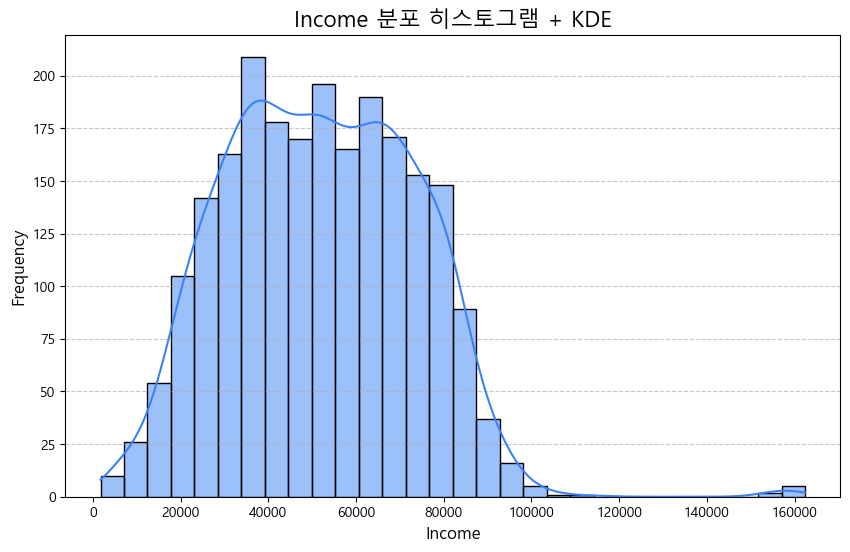

In [12]:
# TODO 1-2(a): Income 히스토그램 + KDE
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df['Income'], bins=30, kde=True, color='#3B82F6', edgecolor='black')

plt.title('Income 분포 히스토그램 + KDE', fontsize=16)
plt.xlabel('Income', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


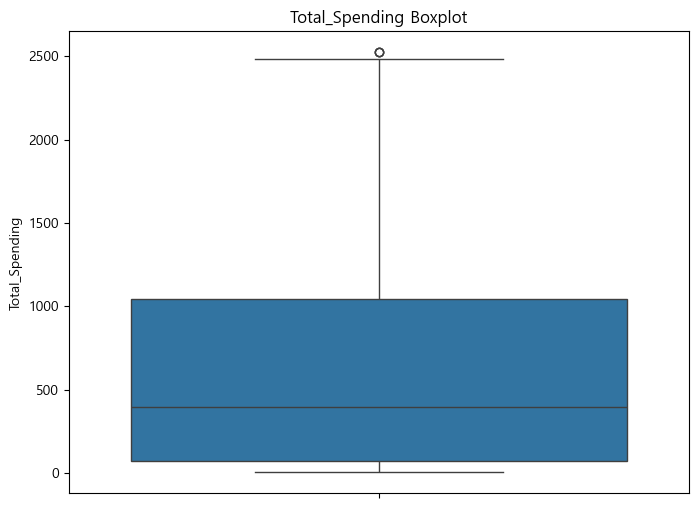

IQR 기준 이상치 갯수: 3
이상치 데이터:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Total_Spending,Total_Purchases,Total_Accepted,Has_Children,Income_Group,Age_Group,Education_Group,Marital_Group,Campaign_Response,Customer_Days
1179,5735,1991,Master,Single,90638.0,0,0,2014-02-13,29,1156,...,2525,17,1,False,High,30대 이하,Postgraduate,Single,True,136
1492,1763,1988,Graduation,Together,87679.0,0,0,2013-07-27,62,1259,...,2524,28,4,False,High,30대 이하,Graduate,Together,True,337
1572,5350,1991,Master,Single,90638.0,0,0,2014-02-13,29,1156,...,2525,17,2,False,High,30대 이하,Postgraduate,Single,True,136


In [13]:
# TODO 1-2(b): Total_Spending 박스플롯 + IQR 기준 이상치
# boxplot
plt.figure(figsize=(8,6))
sns.boxplot(y=df['Total_Spending'])
plt.title('Total_Spending Boxplot')
plt.ylabel('Total_Spending')
plt.show()

#IQR
Q1 = df['Total_Spending'].quantile(0.25)
Q3 = df['Total_Spending'].quantile(0.75)
IQR = Q3-Q1

#이상치
lower_outline = Q1-1.5*IQR
upper_outline = Q3+1.5*IQR
outliers = df[(df['Total_Spending'] < lower_outline) | (df['Total_Spending'] > upper_outline)]

print(f"IQR 기준 이상치 갯수: {len(outliers)}")
print("이상치 데이터:")
display(outliers)

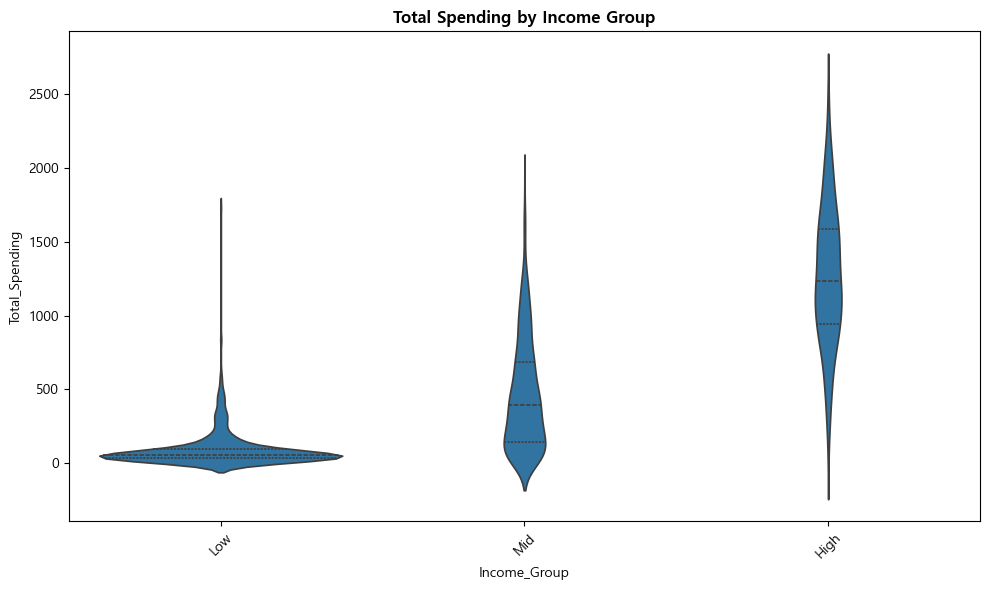

In [14]:
# TODO 1-2(c): Income_Group별 Total_Spending 바이올린 플롯

plt.figure(figsize=(10, 6))
sns.violinplot(x='Income_Group', y='Total_Spending', data=df, inner='quartile')
plt.title('Total Spending by Income Group', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 문제 1-3. 왜도와 첨도

6개 소비 카테고리(MntWines ~ MntGoldProds)의 왜도(Skewness)와 첨도(Kurtosis)를 계산하고,
2×3 히스토그램 그리드를 그려 분포 형태를 비교하세요.

**왜도 해석**
- 왜도 > 0: 오른쪽 꼬리가 긴 분포 
- 왜도 < 0: 왼쪽 꼬리가 긴 분포 
- 왜도 ≈ 0: 좌우 대칭에 가까운 분포

**첨도 해석** 
- 초과 첨도 > 0: 정규분포보다 중앙이 뾰족하고 꼬리가 두꺼운 분포 
- 초과 첨도 < 0: 정규분포보다 중앙이 평평하고 꼬리가 얇은 분포
- 초과 첨도 ≈ 0: 정규분포와 유사한 형태

In [15]:
spending_names = ['MntWines', 'MntFruits', 'MntMeatProducts', 
                  'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
hist_colors = [COLORS['blue'], COLORS['violet'], COLORS['teal'],
               COLORS['emerald'], COLORS['amber'], COLORS['rose']]

# TODO 1-3(a): 6개 카테고리의 왜도/첨도 계산 및 출력
skew_names = df[spending_names].skew()
kurt_names = df[spending_names].kurt()

for col in spending_names:
    print(f"[{col}]")
    print(f"왜도: {skew_names[col]:.4f}")
    print(f"첨도: {kurt_names[col]:.4f}")
    print("-" * 30)


[MntWines]
왜도: 1.1760
첨도: 0.6005
------------------------------
[MntFruits]
왜도: 2.1042
첨도: 4.0698
------------------------------
[MntMeatProducts]
왜도: 2.0853
첨도: 5.5301
------------------------------
[MntFishProducts]
왜도: 1.9200
첨도: 3.0960
------------------------------
[MntSweetProducts]
왜도: 2.1357
첨도: 4.3721
------------------------------
[MntGoldProds]
왜도: 1.8851
첨도: 3.5583
------------------------------


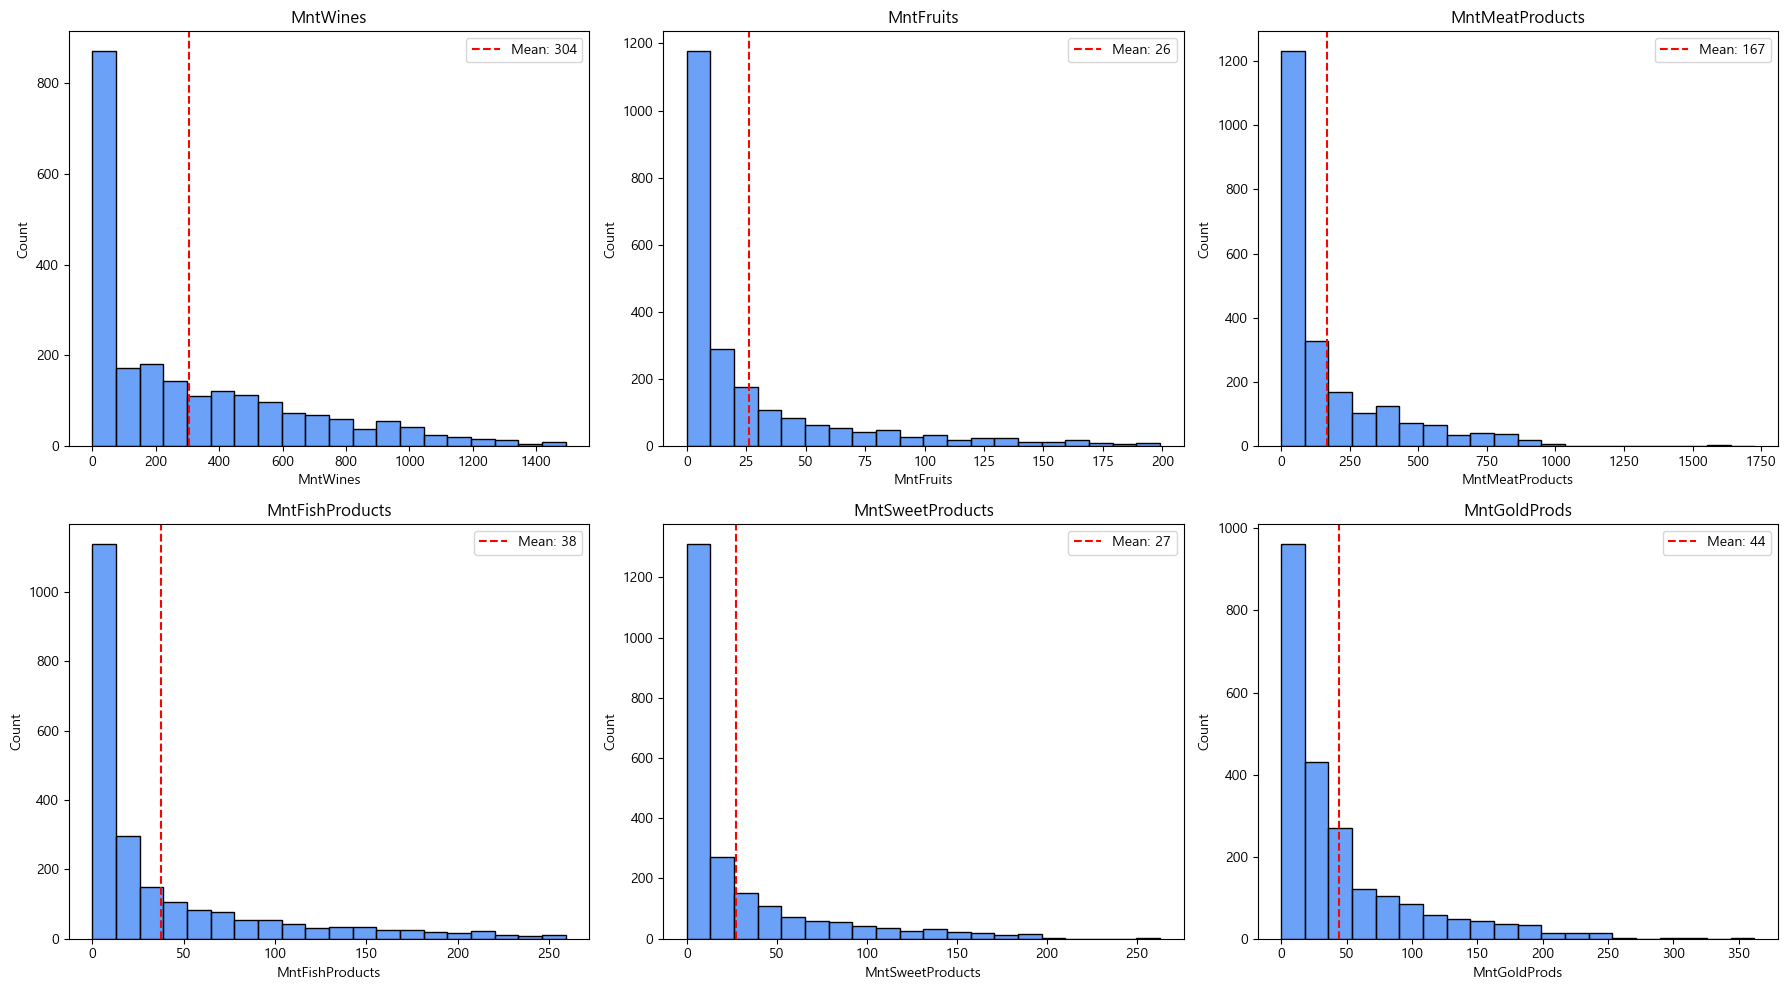

In [16]:
# TODO 1-3(b): 2×3 히스토그램 그리드 (각 카테고리 분포 + 평균선)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(spending_cols):
    sns.histplot(df[col],bins=20, kde=False, ax=axes[i], color=COLORS['blue'])
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:,.0f}')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

### 문제 1-4. 비즈니스 인사이트 정리

Part 1의 분석 결과를 바탕으로 다음을 정리하세요.

1. 고객 특성 요약 (연령, 소득, 소비 특성)
2. 핵심 발견 사항 (분포 특성, 그룹 간 차이)
3. 후속 분석에서 검증할 가설 (최소 3개)

In [17]:
# TODO 1-4: 비즈니스 인사이트 정리
print("4. 비즈니스 인사이트 정리")
print(f"        전체 고객 수: {len(df['Age'])}명")
print(f"        연령 범위: {df['Age'].min()}세 ~ {df['Age'].max()}세")
print(f"        소득 범위: {df['Income'].min():.0f} 원 ~ {df['Income'].max():.0f} 원")

print(" 핵심 발견 사항: ")
print("     소득이 높을수록 총 소비 금액이 많으며, 고액 소비자가 많아 분포도가 더 넓다.")

print("가설 설정: ")
print(  "가설 1. 고소득 고객과 저소득 고객의 소비는 같을 것이다.")
print(  "가설 2. 모든 고객 행동의 패턴은 동일하다.")
print(  "가설 3. 3개의 구매채널(Web, Catalog, Store)의 총 구매 비율은 균등하게 분포할 것이다.")

4. 비즈니스 인사이트 정리
        전체 고객 수: 2236명
        연령 범위: 28세 ~ 84세
        소득 범위: 1730 원 ~ 162397 원
 핵심 발견 사항: 
     소득이 높을수록 총 소비 금액이 많으며, 고액 소비자가 많아 분포도가 더 넓다.
가설 설정: 
가설 1. 고소득 고객과 저소득 고객의 소비는 같을 것이다.
가설 2. 모든 고객 행동의 패턴은 동일하다.
가설 3. 3개의 구매채널(Web, Catalog, Store)의 총 구매 비율은 균등하게 분포할 것이다.


---
## Part 2: 확률분포 모델링 — "고객 행동은 어떤 패턴을 따르는가?"

실제 고객 데이터에 이론적 확률분포를 적합하여 고객 행동을 모델링합니다.

### 문제 2-1. 이항분포 — 캠페인 수락 모델링

`Response` 열에서 수락률 p를 계산하고, 이를 이항분포 B(n, p)에 적용합니다.

- **(a)** 10명 중 정확히 2명이 수락할 확률
  - B(n=10, p) 에서 P(X = 2) 계산

- **(b)** 10명 중 3명 이상이 수락할 확률
  - B(n=10, p) 에서 P(X ≥ 3) 계산

- **(c)** 이항분포 PMF 시각화
  - B(n=10, p) 의 모든 경우(X = 0, 1, ..., 10)에 대한
    이론 확률을 막대그래프로 그립니다.

- **(d)** n=100 으로 확장 — 세 가지 질문
  - **기대 수락자 수**: E(X) 계산
  - **15명 이상 수락 확률**: P(X ≥ 15) 계산
  - **90% 보장 최소 수락 수**: P(X ≤ k) ≥ 0.90 을 만족하는 최솟값 k 탐색

In [18]:
# TODO 2-1(a),(b): 수락률(p) 계산 + P(X=2), P(X≥3) 계산 및 출력
n_trial = 10
p_accept=2/n_trial
camp_accept = stats.binom(n=n_trial, p=p_accept)

print(f"수락률(p)의 확률: {p_accept}")
print(f"P(X=2)일 확률:", camp_accept.pmf(2))
print(f"P(X≥3)일 확률:", 1-camp_accept.cdf(3))

수락률(p)의 확률: 0.2
P(X=2)일 확률: 0.30198988800000004
P(X≥3)일 확률: 0.12087388160000012


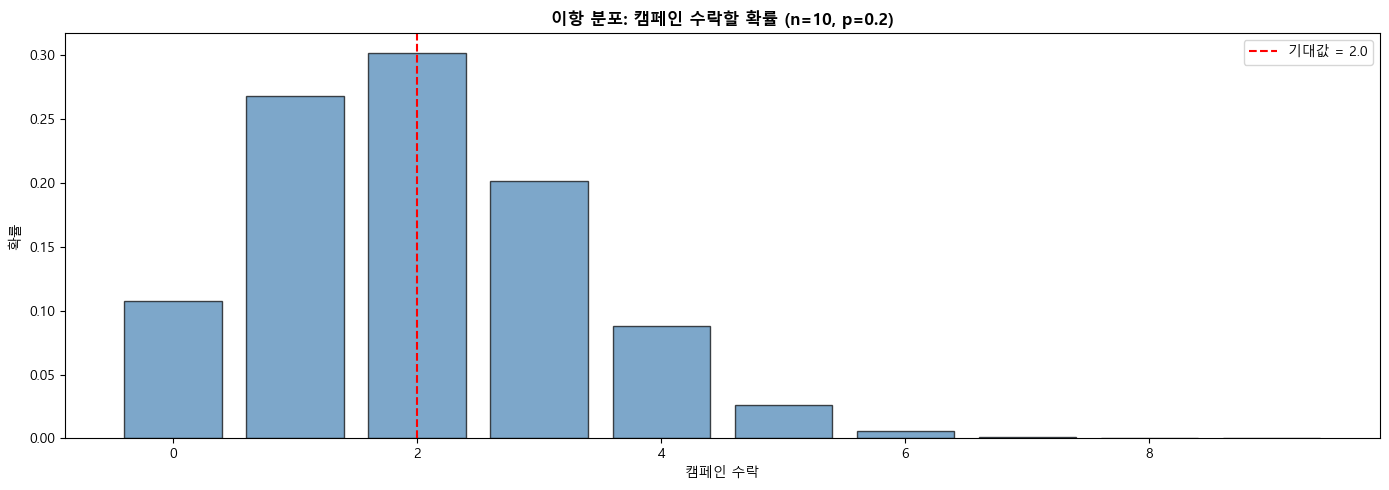

In [19]:
# TODO 2-1(c): 이항분포 PMF 시각화
plt.subplots(figsize=(14, 5))

# PMF 그래프
k = np.arange(0, 10)
pmf = camp_accept.pmf(k)
plt.bar(k, pmf, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(n_trial * p_accept, color='red', linestyle='--',
                label=f'기대값 = {n_trial * p_accept:.1f}')
plt.xlabel('캠페인 수락')
plt.ylabel('확률')
plt.title('이항 분포: 캠페인 수락할 확률 (n=10, p=0.2)', fontweight='bold')
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
# TODO 2-1(d): 100명 발송 시 기대 수락자, P(X≥15), 90% 보장 최소 수락 수
n_campaign = 100
excepted_accept=camp_accept.mean()
camp_accept = stats.binom(n=n_trial, p=p_accept)

print(f"100명 발송 시 기대 수락자: {excepted_accept}")
print(f"P(X≥15)일 확률", 1-camp_accept.cdf(15))
print(f"90% 보장 최소 수락 수", camp_accept.ppf(0.9))

100명 발송 시 기대 수락자: 2.0
P(X≥15)일 확률 0.0
90% 보장 최소 수락 수 4.0


### 문제 2-2. 포아송 분포 — 웹사이트 방문 모델링

`NumWebVisitsMonth`(월간 웹 방문 수)에 포아송 분포를 적합합니다.

- **(a)** λ 추정 및 적합 평가
  - 표본 평균으로 λ를 추정하고,
    표본 평균 ≈ 표본 분산인지 확인하여 포아송 분포 적합 여부를 평가합니다.

- **(b)** 실측 vs 이론 PMF 시각화
  - 각 방문 횟수(0회, 1회, 2회, ...)별 실제 비율(실측 PMF)과
    포아송 분포의 이론 확률(이론 PMF)을 막대그래프로 겹쳐 그려 비교합니다.

- **(c)** 포아송 분포 활용 — 두 가지 실무 시나리오
  - **과다 방문 고객 비율**: P(X ≥ 10) 계산
    → 추정된 포아송 분포에서 월 10회 이상 방문할 확률이 몇 %인지 구합니다.
  - **서버 용량 계획**: 상위 5% 기준값 k 계산, 즉 P(X ≤ k) = 0.95 를 만족하는 k 탐색
    → 전체 고객의 95%를 커버할 수 있는 최대 방문 횟수를 구하고,
       이를 서버가 처리해야 할 기준 용량으로 활용합니다.

In [21]:
web_visits = df['NumWebVisitsMonth']

# TODO 2-2(a): 람다 추정 및 포아송 적합 평가 (월간 웹 방문수 평균≈분산 값이 비슷한지 확인)
lambda_visits = web_visits.mean()
poisson_visits = stats.poisson(mu=lambda_visits)

var_visits = web_visits.var()
print("(a): 람다 추정 및 포아송 적합 평가")
print(f"평균(lambda)추정값: {lambda_visits:.4f}")
print(f"분산: {var_visits:.4f}")

if abs(lambda_visits-var_visits)<1:
    print("평균과 분산이 비슷하므로, 포아송 분포에 적합하다.")
else:
    print("평균과 분산의 차이가 크므로, 포아송 분포에 적합하지 않다.")

(a): 람다 추정 및 포아송 적합 평가
평균(lambda)추정값: 5.3189
분산: 5.8898
평균과 분산이 비슷하므로, 포아송 분포에 적합하다.


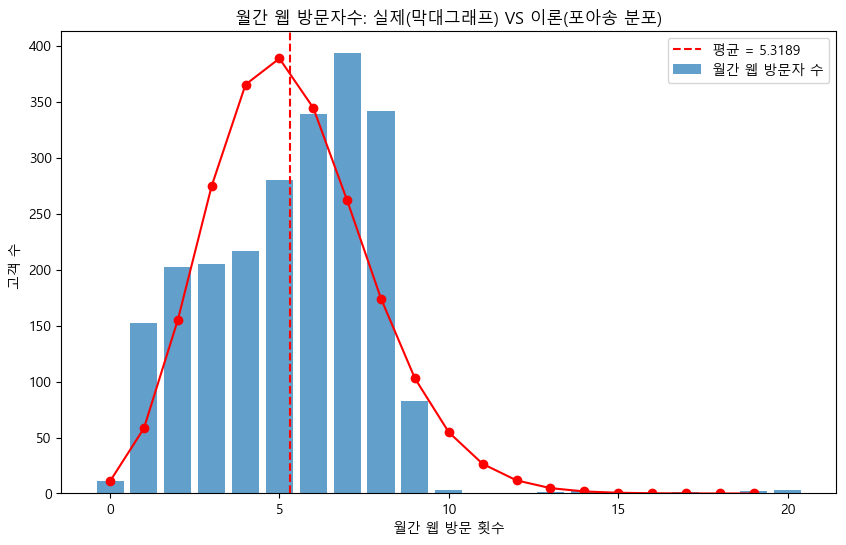

In [22]:
# TODO 2-2(b): 월간 웹 방문수 막대그래프 vs 이론 PMF 비교 시각화 (두 그래프를 겹쳐서 그리기)
plt.figure(figsize=(10,6))
class_counts = web_visits.value_counts()

k = np.arange(0, 20)
pmf = poisson_visits.pmf(k)
excepted_counts = pmf *len(web_visits)

#막대 차트
plt.bar(class_counts.index, class_counts.values, alpha= 0.7, label= '월간 웹 방문자 수')

# PMF
plt.plot(k, excepted_counts, 'o-', color='red')
plt.axvline(lambda_visits, color='red', linestyle='--', label=f'평균 = {lambda_visits:.4f}')
plt.xlabel('월간 웹 방문 횟수')
plt.ylabel('고객 수 ')
plt.title('월간 웹 방문자수: 실제(막대그래프) VS 이론(포아송 분포)')
plt.legend()
plt.show()


In [23]:
# TODO 2-2(c):
# - 과다 방문 고객: 포아송 분포로 P(X ≥ 10) 계산 (월 10회 이상 방문 확률)
heavy_threshold = 10
poisson_visit_2 = stats.poisson(mu=heavy_threshold)
print(f"과다 방문 고객(P(X ≥ 10)): {poisson_visit_2.sf(9):.4f}")
print(f"     -> 월 10회 이상 방문할 확률은 {poisson_visit_2.sf(9):.4f}이다. ")

# - 서버 용량 계획: P(X ≤ k) ≥ 0.95 를 만족하는 최솟값 k 탐색 (상위 5% 기준)
k = 0
while poisson_visit_2.cdf(k) < 0.95:
    k += 1
print(f"P(X ≤ k) ≥ 0.95 를 만족하는 최솟값 k: {k}")

과다 방문 고객(P(X ≥ 10)): 0.5421
     -> 월 10회 이상 방문할 확률은 0.5421이다. 
P(X ≤ k) ≥ 0.95 를 만족하는 최솟값 k: 15


### 문제 2-3. 정규분포 — 소득 모델링

`Income`에 정규분포를 적합합니다.
Part 1에서 Income의 왜도가 작고 평균≈중앙값임을 확인했습니다. 정규분포가 잘 맞을까요?

- **(a)** μ, σ 추정 후 CDF로 P(Income < 30000), P(Income > 80000) 계산,
 PPF로 상위 10% 소득 기준값 계산 — **이론 확률과 실측 비율을 비교**하세요
- **(b)** 히스토그램 + 정규 분포 PDF와 겹쳐 그리기
- **(c)** 정규분포 활용 — 두 가지 질문
  - **VIP 기준선**: 상위 5% 소득 기준값
    → "이 금액 이상이면 VIP 고객으로 분류"
  - **할인 대상 기준선**: 하위 10% 소득 기준값
    → "이 금액 이하이면 할인 대상 고객으로 분류"


In [24]:
# TODO 2-3(a): μ, σ 추정 → CDF로 P(Income<30000), P(Income>80000) 계산
#               PPF로 상위 10% 소득 기준값 계산 → 이론 확률과 실측 비율 비교
mu = np. mean(web_visits)
sigma = np.std(web_visits, ddof=1)
norm_dist = stats.norm(loc=mu, scale=sigma)

print (f"평균 소득: {mu:.4f}")
print(f"표준편차: {sigma:.4f}")

p_under_30k = stats.norm.cdf(30000, loc=mu, scale=sigma)
p_under_80k = 1- stats.norm.cdf(80000, loc=mu, scale=sigma)
print(f"P(Income < 30000) = {p_under_30k}")
print(f"P(Income > 80000) = {p_under_80k}")

#PPF(상위 10% 소득 기준값 계산)
top_10 = norm_dist.ppf(0.9)
print('상위 10% 소득 기준값 계산:')
print(f'    -> 실측 확률: {top_10}')
print(f'    -> 이론 확률: 0.1')
print(f'    -> 이론 확률과 실제 확률의 차이 {top_10-0.1:.4f}')


평균 소득: 5.3189
표준편차: 2.4269
P(Income < 30000) = 1.0
P(Income > 80000) = 0.0
상위 10% 소득 기준값 계산:
    -> 실측 확률: 8.429051945547517
    -> 이론 확률: 0.1
    -> 이론 확률과 실제 확률의 차이 8.3291


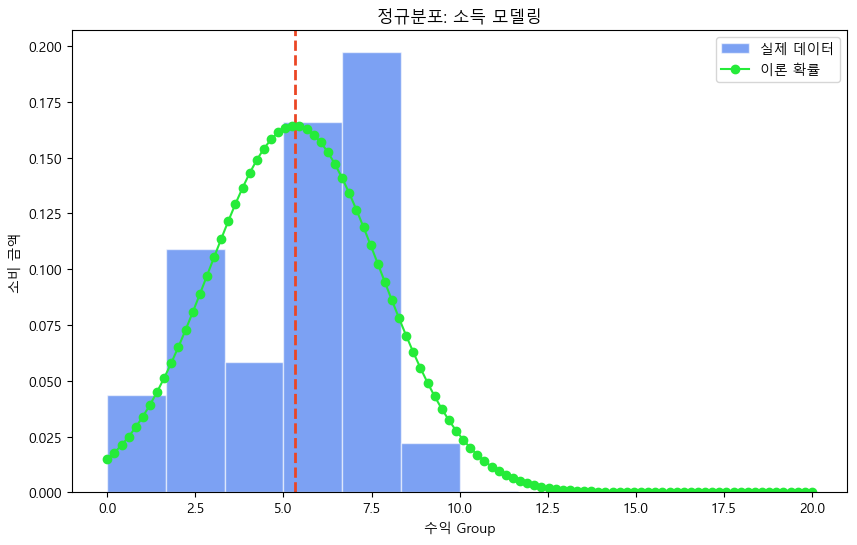

In [25]:
# TODO 2-3(b): 히스토그램 + 정규 PDF 겹쳐 그리기

plt.figure(figsize=(10,6))
class_counts = web_visits.value_counts()

#히스토그램
plt.hist(web_visits, bins=12, density=True, alpha=0.6, color='#2563EB', edgecolor='white', label='실제 데이터')
plt.axvline(mu, color="#EB4625", linestyle='--', linewidth=2)

# PDF
k=np.linspace(web_visits.min(), web_visits.max(), 100)
pdf = stats.norm.pdf(k, mu, sigma)
plt.plot(k, pdf, 'o-', color="#25EB39", label='이론 확률')
plt.xlabel('수익 Group')
plt.ylabel('소비 금액')
plt.title('정규분포: 소득 모델링')
plt.legend()
plt.show()


In [26]:
# TODO 2-3(c): 실무 시나리오 — VIP(상위 5%) 기준선 + 할인 대상(하위 10%) 기준선
vip = norm_dist.ppf(0.95)
sales_people = norm_dist.ppf(0.1)
print(f"VIP(상위 5%): {vip:.4f}")
print(f"할인 대상 기준선(하위 10%): {sales_people:.4f}")

VIP(상위 5%): 9.3107
할인 대상 기준선(하위 10%): 2.2087


---
## Part 3: 추정과 가설검정 — "고소득 고객과 저소득 고객의 소비는 다른가?"

신뢰구간과 가설검정을 통해 고객 그룹 간 차이를 통계적으로 검증합니다.

### 문제 3-1. 신뢰구간 추정

- **(a)** Total_Spending 평균의 90%, 95%, 99% 신뢰구간을 계산하세요.
- **(b)** Income_Group별 95% CI를 계산하고 오차막대 그래프로 비교하세요.

CI = [x̄ - t × SE, x̄ + t × SE] (SE = s / √n)

In [27]:
# TODO 3-1(a): Total_Spending 평균의 신뢰구간 (90%, 95%, 99%)
# CI = x̄ ± t(α/2, n-1) × SE
n = len(df['Total_Spending'])
xbar= np.mean(n)
s = np.std(df['Total_Spending'], ddof=1)
se = s / np.sqrt(n)

for i in [0.9, 0.95, 0.99]:
    alpha = 1-i
    

    t_crit = stats.t.ppf(1-alpha/2, df=n-1)
    margin = t_crit * se
    
    ci_low = xbar - margin
    ci_high = xbar + margin
    print(f"신뢰수준 {i*100} CI: {ci_low:.4f}, {ci_high:.4f}") 

신뢰수준 90.0 CI: 2215.0555, 2256.9445
신뢰수준 95.0 CI: 2211.0399, 2260.9601
신뢰수준 99.0 CI: 2203.1866, 2268.8134


Income_Group
Low     1725.652033
Mid     1847.097823
High    1536.363240
Name: Income, dtype: float64


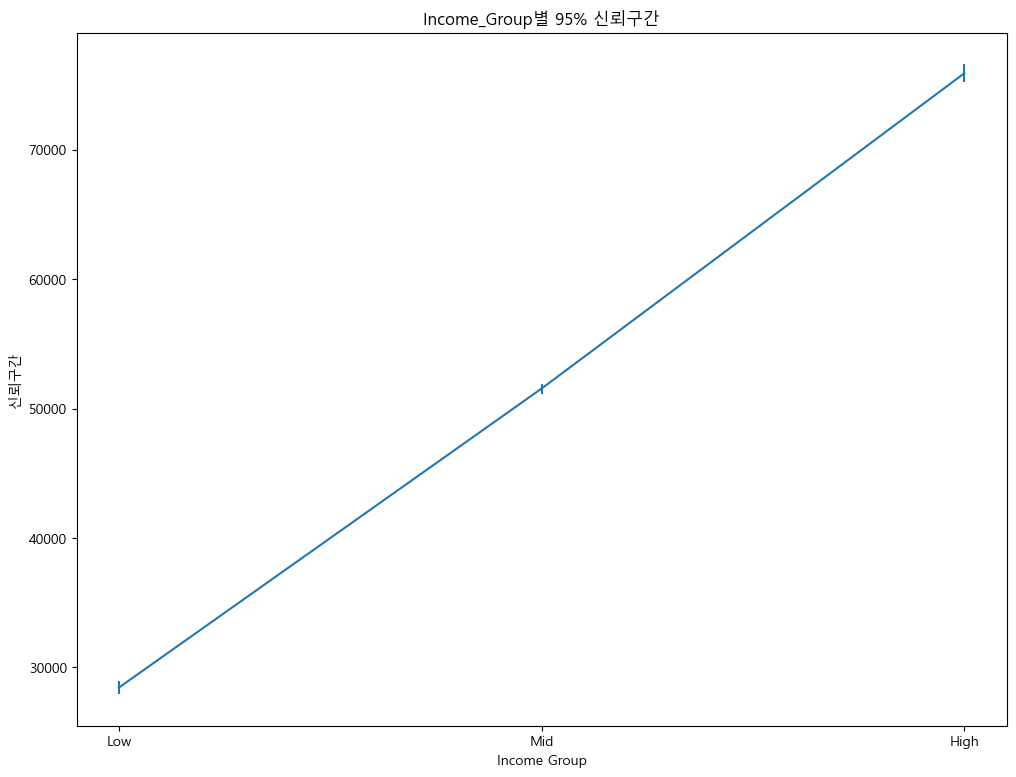

In [28]:
# TODO 3-1(b): Income_Group별 95% CI 계산 + 오차막대 그래프
grouped_income = df.groupby("Income_Group")["Income"]
mean_income = grouped_income.mean()
std_income = grouped_income.std()
n_income = grouped_income.count()

t_one = stats.t.ppf(0.95, df=n_income-1) 
se_income = std_income / np.sqrt(n_income)
lower_bound = xbar - t_one * se_income
print(lower_bound)

#오차 막대 그래프
plt.figure(figsize=(12,9))
plt.errorbar(x=mean_income.index, y=mean_income.values, yerr=t_one* se_income.values)
plt.xlabel("Income Group")
plt.ylabel("신뢰구간")
plt.title("Income_Group별 95% 신뢰구간")
plt.show()


### 문제 3-2. 독립표본 t-검정 (Welch's t-test)

**가설**: 자녀가 없는 고객의 총 소비가 자녀가 있는 고객과 다른가?

- H₀: μ_무자녀 = μ_유자녀
- H₁: μ_무자녀 ≠ μ_유자녀

Cohen's d 해석 기준: |d| < 0.5 작은, 0.5~0.8 중간, > 0.8 큰 효과

In [29]:
no_child = df[~df['Has_Children']]['Total_Spending']
yes_child = df[df['Has_Children']]['Total_Spending']

# TODO 3-2: Welch's t-검정 수행 + Cohen's d 계산 + 결과 출력
# Welch's t-검정 
t_stat_child, p_value_child = stats.ttest_ind(no_child, yes_child, equal_var=False) #equal_var: 두그룹의 분산이 같은이 유무
alpha = 0.05
# 유의수준 a = 0.05
if p_value_child > alpha:
    print(f"해석: p_value {p_value_child}가 유의수준{alpha}보다 크므로, 자녀가 없는 고객의 총 소비가 자녀가 있는 고객과 다르다고 할 수 없다.(귀무가설 기각 실패) ")
else:    
    print(f"해석: p_value {p_value_child}가 유의수준{alpha}작거나 같으므로, 자녀가 없는 고객의 총 소비가 자녀가 있는 고객의 총 소비와 같다고 할 증거가 부족하다.(귀무가설 기각) ")

# Cohen's d 계산
def cohens_d_ind(no_child, yes_child):
    """Cohen's d — 독립표본: d = |x̄₁ - x̄₂| / s_pooled"""
    n1, n2 = len(no_child), len(yes_child)
    var1 = np.var(no_child, ddof=1)
    var2 = np.var(yes_child, ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)) # 합동 분산 
    return abs(np.mean(no_child) - np.mean(yes_child)) / s_pooled

d_one = cohens_d_ind(no_child, yes_child)

if abs(d_one) < 0.5:
    print(f"해석: Cohen's d(값: {d_one:.4f})은 작은 효과이다.")
elif abs(d_one) < 0.8:
    print(f"해석: Cohen's d(값: {d_one:.4f})은 중간 효과이다.")
else:
    print(f"해석: Cohen's d(값: {d_one:.4f})은 큰 효과이다.")

해석: p_value 6.321230429385628e-105가 유의수준0.05작거나 같으므로, 자녀가 없는 고객의 총 소비가 자녀가 있는 고객의 총 소비와 같다고 할 증거가 부족하다.(귀무가설 기각) 
해석: Cohen's d(값: 1.3599)은 큰 효과이다.


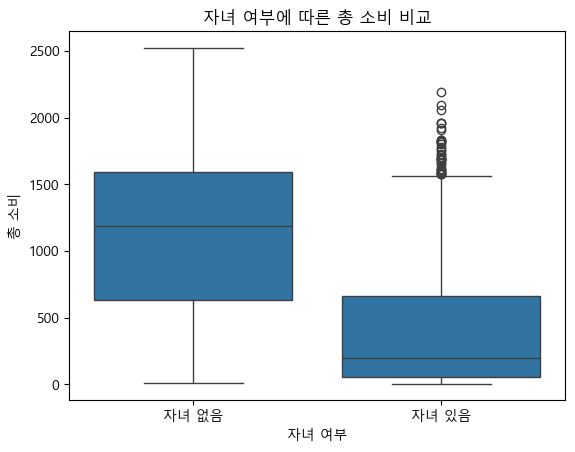

In [30]:
# TODO 3-2(c): 박스플롯 비교 시각화
df['Children_Label'] = df['Has_Children'].map({True: "자녀 있음", False: "자녀 없음"})
sns.boxplot(x='Children_Label', y='Total_Spending', data=df)
plt.title("자녀 여부에 따른 총 소비 비교")
plt.xlabel("자녀 여부")
plt.ylabel("총 소비")
plt.show()


### 문제 3-3. 대응표본 t-검정

같은 고객의 **와인 소비**(`MntWines`)와 **육류 소비**(`MntMeatProducts`)를 비교합니다.

- H₀: μ_Wine = μ_Meat (차이 = 0)
- H₁: μ_Wine ≠ μ_Meat

In [31]:
wines = df['MntWines']
meat = df['MntMeatProducts']

# TODO 3-3: 차이 계산 + 대응표본 t-검정 + Cohen's d + 결과 출력
t_stat, p_value = stats.ttest_rel(wines, meat)
p_value  = p_value / 2 if t_stat < 0 else  1 - p_value / 2 # 양측검정의 p값을 2로 나눠서 단측 검정의 p값으로 한다

alpha = 0.05
if  p_value <= alpha :
    print(f'p값({p_value})은 유의수준(a=0.05)보다 작거나 같음 -> H0 귀무가설 기각 : 와인의 소비와 육류의 소비는 차이가 있다고 할 근거가 부족하다.')
else :
    print(f'p값({p_value})은 유의수준(a=0.05)보다 큼 ->H0 귀무가설 지지 : 와인의 소비와 육류의 소비는 차이가 있다고 할 수 있다.')
    
#Cohen's d
d_two = cohens_d_ind(wines, meat)

if abs(d_two) < 0.5:
    print(f"해석: Cohen's d(값: {d_two:.4f})은 작은 효과이다.")
elif abs(d_two) < 0.8:
    print(f"해석: Cohen's d(값: {d_two:.4f})은 중간 효과이다.")
else:
    print(f"해석: Cohen's d(값: {d_two:.4f})은 큰 효과이다.")

p값(1.0)은 유의수준(a=0.05)보다 큼 ->H0 귀무가설 지지 : 와인의 소비와 육류의 소비는 차이가 있다고 할 수 있다.
해석: Cohen's d(값: 0.4786)은 작은 효과이다.


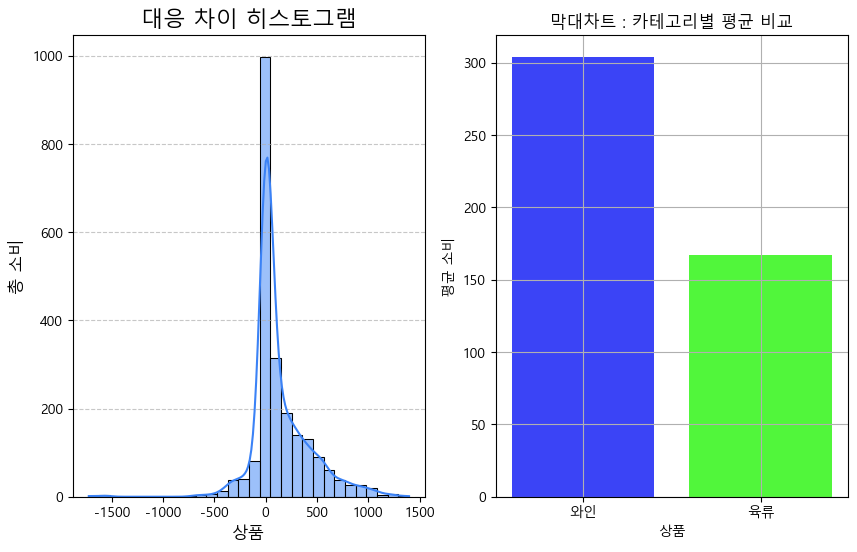

In [32]:
# TODO 3-3(b): (1) 대응 차이 히스토그램 (2) 카테고리별 평균 비교 막대그래프
diff = df['MntWines'] - df['MntMeatProducts']
categories = [df['MntWines'].mean(), df['MntMeatProducts'].mean()]
category_labels = ['와인', '육류']
#1) 대응 차이 히스토그램
fig, axes = plt.subplots(1, 2, figsize=(10,6))
sns.histplot(diff, bins=30, kde=True, color='#3B82F6', edgecolor='black', ax=axes[0])
axes[0].set_title('대응 차이 히스토그램', fontsize=16)
axes[0].set_xlabel('상품', fontsize=12)
axes[0].set_ylabel('총 소비', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

#2) 카테고리별 평균 비교 막대그래프
axes[1].bar(category_labels, categories, color=["#3B44F6", "#51F63B"])
axes[1].set_xlabel('상품')
axes[1].set_ylabel('평균 소비')
axes[1].set_title("막대차트 : 카테고리별 평균 비교")
axes[1].grid(True)


### 문제 3-4. 검정력 분석

- **(a)** 문제 3-2의 효과 크기와 표본 크기를 사용하여 검정력(Power)을 계산하세요.
- **(b)** 작은 효과(d=0.2)를 탐지하기 위해 필요한 그룹당 표본 크기를 구하세요.

In [33]:
power_analysis = TTestIndPower()
n1, n2 = len(no_child), len(yes_child)
# TODO 3-4(a): 문제 3-2 기준 검정력 계산
power = power_analysis.solve_power(effect_size=d_one, nobs1=n1, alpha=0.05, alternative='two-sided')
print(f"검정력: {power}")
print(f"    -> 자녀의 유무에 따른 차이를 충분히 잡을 수 있다.")

# TODO 3-4(b): 작은 효과(d=0.2) 탐지에 필요한 표본 크기 산정
n = power_analysis.solve_power(effect_size=0.2, nobs1=None, alpha=0.05, power=0.80, alternative='two-sided')
print(f"작은 효과(d=0.2) 탐지에 필요한 표본 크기: {n:.4f}")

검정력: 1.0
    -> 자녀의 유무에 따른 차이를 충분히 잡을 수 있다.
작은 효과(d=0.2) 탐지에 필요한 표본 크기: 393.4057


---
## Part 4: 고급 검정 — "교육, 결혼, 캠페인 반응의 관계는?"

정규성 검정을 바탕으로 적절한 검정 방법을 선택하고,
범주형 변수 간 관계를 분석합니다.

### 문제 4-1. 정규성 + 등분산 검정

Education_Group별 Total_Spending의 정규성을 Shapiro-Wilk 검정과 Q-Q Plot으로 확인하세요.
정규성이 기각되더라도, 표본이 충분히 크면(n ≥ 30) 중심극한정리(CLT)에 의해
ANOVA가 여전히 강건(robust)합니다. 각 그룹의 표본 크기도 함께 확인하세요.

⚠️ **등분산성 위반은 CLT와 무관합니다** — 표본이 아무리 커도 해결되지 않습니다.
Levene 검정으로 등분산 가정을 확인하고, 위반 시 Welch's ANOVA를 사용합니다.

In [34]:
edu_groups = ['Undergraduate', 'Graduate', 'Postgraduate']
undergrad = df[df['Education_Group'] == 'Undergraduate']['Total_Spending']
grad = df[df['Education_Group'] == 'Graduate']['Total_Spending']
postgrad = df[df['Education_Group'] == 'Postgraduate']['Total_Spending']

# TODO 4-1(a): Shapiro-Wilk 검정 (각 그룹별)
print("(a): Shapiro-Wilk 검정 (각 그룹별)")
norm_edu = True
for name, data in zip(edu_groups, [undergrad, grad, postgrad]):
    # TODO: Shapiro-Wilk 정규성 검정 수행
    stat, p = stats.shapiro(data)
    data = data.dropna()

    result = "정규성 유지" if (p is not None and p > 0.05) else "정규성 위반"
    if p is not None and p <= 0.05:
        norm_edu = False
    stat_edu = stat if stat is not None else 0
    p_edu = p if p is not None else 0
    print(f"  {name}: W={stat_edu:.4f}, p={p_edu:.4f} ({result})")

# TODO 4-1(b): Levene 등분산 검정 → use_welch = True/False 설정
lev_stat, lev_p = stats.levene(undergrad, grad, postgrad)

lev_stat_edu= lev_stat if lev_stat is not None else 0
lev_p_edu = lev_p if lev_p is not None else 0
print(f"  F = {lev_stat_edu:.4f}, p = {lev_p_edu:.4f}")
use_welch = 0

if p > 0.05:
    use_welch = False
else:
    use_welch = True
print("(b): Levene 등분산 검정 ")
print(f"    -> Levene 등분산 검정 결과: {use_welch}")

(a): Shapiro-Wilk 검정 (각 그룹별)
  Undergraduate: W=0.7605, p=0.0000 (정규성 위반)
  Graduate: W=0.8743, p=0.0000 (정규성 위반)
  Postgraduate: W=0.8765, p=0.0000 (정규성 위반)
  F = 13.2893, p = 0.0000
(b): Levene 등분산 검정 
    -> Levene 등분산 검정 결과: True


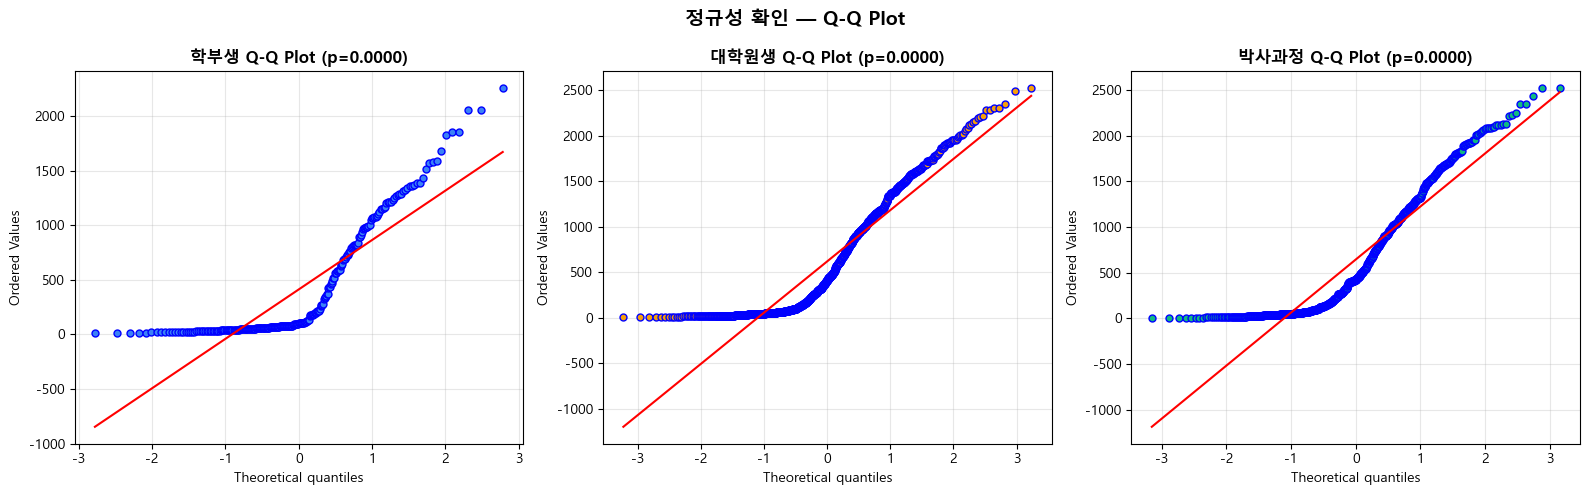

In [35]:
# TODO 4-1(b): Q-Q Plot (1×3 서브플롯)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("정규성 확인 — Q-Q Plot", fontsize=14, fontweight='bold')

for ax, data, name, color in [(axes[0], undergrad, '학부생', '#3B82F6'),
                                (axes[1], grad, '대학원생', '#F59E0B'),
                                (axes[2], postgrad, '박사과정', '#10B981')]:
    stats.probplot(data, dist="norm", plot=ax)
    sw_p = stats.shapiro(data).pvalue
    ax.set_title(f"{name} Q-Q Plot (p={sw_p:.4f})", fontsize=12, fontweight='bold')
    ax.get_lines()[0].set_markerfacecolor(color)
    ax.get_lines()[1].set_markeredgecolor(color)
    ax.get_lines()[0].set_markersize(5)
    ax.get_lines()[1].set_color('red')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 문제 4-2. ANOVA + 사후검정

문제 4-1의 정규성/등분산 검정 결과에 따라 적절한 검정을 수행합니다.

- 등분산 만족 → One-way ANOVA + **Tukey HSD** + Cohen's d
- 등분산 위반 → Welch's ANOVA + **Games-Howell** (`pg.pairwise_gameshowell()`) + Hedges' g
- 참고로 비모수 검정(Kruskal-Wallis)도 병행하여 결과의 일관성을 확인하세요.
- 효과 크기: η² + ω² (기준: 0.01 작은, 0.06 중간, 0.14 큰)
- 쌍별 효과 크기: Cohen's d / Hedges' g (기준: 0.2 미만 매우 작은, 0.2~0.5 작은, 0.5~0.8 중간, 0.8 이상 큰)

In [36]:
group_data = {g: df[df['Education_Group'] == g]['Total_Spending'].values for g in edu_groups}

# TODO 4-2(a): use_welch에 따라 ANOVA / Welch's ANOVA 수행 (Kruskal-Wallis도 병행)
# Welch's ANOVA
welch = pg.welch_anova(dv='Total_Spending', between='Education_Group', data=df)
display(welch)
f_val = welch['F'].values[0] 
p_val = welch['p-unc'].values[0] 
eta = welch['np2'].values[0] 

if p_val is not None:
    verdict = 'H₀ 기각: 교육 그룹별 총 소비량은 유의한 차이가 있습니다' if p_val < 0.05 else 'H₀ 기각 실패'
    print(f"판정: {verdict}")

if eta is not None:
    size_eta = '작은' if eta < 0.06 else '중간' if eta < 0.14 else '큰'
    print(f"  [효과크기] η² = {eta:.4f} ({size_eta} 효과)")

# Kruskal-Wallis (비모수)
h_stat, kw_p = stats.kruskal(*group_data.values())

print(f"  H 통계량: {h_stat:.4f}")
print(f"  p-value: {kw_p:.4f}")

# η²_H 효과크기 계산
# 공식: η²_H = (H − k + 1) / (N − k)  (k=집단수, N=전체 표본 크기)
k3 = 3
N3 = len('Undergraduate') + len('Graduate') + len('Postgraduate')
edu = pg.anova(dv='Total_Spending', between='Education_Group', data=df, detailed=True)
eta_sq_h3 = (h_stat - k3 + 1) / (N3 - k3)

if h_stat is not None:
    print(f"  H 통계량: {h_stat:.4f}")
    print(f"  p-value: {kw_p:.4f}")

if eta_sq_h3 is not None:
    size_eta3 = '작은' if eta_sq_h3 < 0.06 else '중간' if eta_sq_h3 < 0.14 else '큰'
    print(f"\n  [효과크기] η²_H = {eta_sq_h3:.4f} ({size_eta3} 효과)")

if kw_p is not None:
    verdict3 = 'H₀ 기각: 교육 그룹별 총 소비량은 유의한 차이가 있습니다' if kw_p < 0.05 else 'H₀ 기각 실패'
    print(f"  판정: {verdict3}")


# TODO 4-2(b): η² + ω² 계산 — ω² = (SS_between - (k-1)*MS_within) / (SS_total + MS_within)
eta_sq = edu['np2'].values[0] 
print(f"    η² (에타제곱) = {eta_sq:.4f}")

ss_b = edu['SS'].values[0]  
ss_w = edu['SS'].values[1]  
df_b = edu['DF'].values[0]  
ms_w = edu['MS'].values[1]  

ss_t = ss_b + ss_w          
omega_sq = (ss_b - df_b * ms_w) / (ss_t + ms_w)
print(f"    ω² (오메가제곱) = {omega_sq:.4f}")


# 판정
if p_val is not None:
    verdict = 'H₀ 기각: 적어도 하나의 집단 평균이 다릅니다' if p_val < 0.05 else 'H₀ 기각 실패: 집단 평균이 모두 같다고 볼 수 있습니다'
    print(f" 판정 (α=0.05): {verdict}")

# 효과크기 해석
if eta_sq is not None:
    size_eta = '작은' if eta_sq < 0.06 else '중간' if eta_sq < 0.14 else '큰'
    print(f"[효과크기] η² = {eta_sq:.4f} ({size_eta} 효과)")

,Source,ddof1,ddof2,F,p-unc,np2
0,Education_Group,2,751.708152,19.817377,4.098696e-09,0.0137


판정: H₀ 기각: 교육 그룹별 총 소비량은 유의한 차이가 있습니다
  [효과크기] η² = 0.0137 (작은 효과)
  H 통계량: 36.6133
  p-value: 0.0000
  H 통계량: 36.6133
  p-value: 0.0000

  [효과크기] η²_H = 1.1538 (큰 효과)
  판정: H₀ 기각: 교육 그룹별 총 소비량은 유의한 차이가 있습니다
    η² (에타제곱) = 0.0137
    ω² (오메가제곱) = 0.0128
 판정 (α=0.05): H₀ 기각: 적어도 하나의 집단 평균이 다릅니다
[효과크기] η² = 0.0137 (작은 효과)


In [37]:
# TODO 4-2(c): 사후검정 수행 + 해석 + 쌍별 효과크기
# 등분산 만족 → Tukey HSD + Cohen's d
# 등분산 위반 → Games-Howell (pg.pairwise_gameshowell) + Hedges' g
if p_val is not None and p_val < 0.05:
    gh2 = pg.pairwise_gameshowell(dv='Total_Spending', between='Education_Group', data=df)
    display(gh2)

# Hedges'g
from itertools import combinations
group_data = {g: df[df['Education_Group'] == g]['Total_Spending'].values for g in ['Undergraduate', 'Graduate', 'Postgraduate']}
for (group_name1, group_data1), (group_name2, group_data2) in combinations(group_data.items(), 2): #조합 3C2 = 3개중에 2개를 뽑음
    # eftype='cohen': 일반 Cohen's d (편향 있음, 대표본에서 문제 없음)
    # eftype='hedges': Hedges' g (편향 조정, 소표본에서 권장)
    d = pg.compute_effsize(group_data1, group_data2, eftype='cohen')
    size_d = '매우 작은' if abs(d) < 0.2 else '작은' if abs(d) < 0.5 else '중간' if abs(d) < 0.8 else '큰'
    print(f"  {group_name1} vs {group_name2}: d = {d:.3f} ({size_d} 효과)")

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,Graduate,Postgraduate,620.394316,644.791813,-24.397497,27.691976,-0.881031,1808.339544,6.523632e-01,-0.040121
1,Graduate,Undergraduate,620.394316,412.254902,208.139414,36.852786,5.647861,425.032927,8.920656e-08,0.355688
2,Postgraduate,Undergraduate,644.791813,412.254902,232.536911,38.554847,6.031328,492.811108,9.577128e-09,0.389636


  Undergraduate vs Graduate: d = -0.356 (작은 효과)
  Undergraduate vs Postgraduate: d = -0.390 (작은 효과)
  Graduate vs Postgraduate: d = -0.040 (매우 작은 효과)


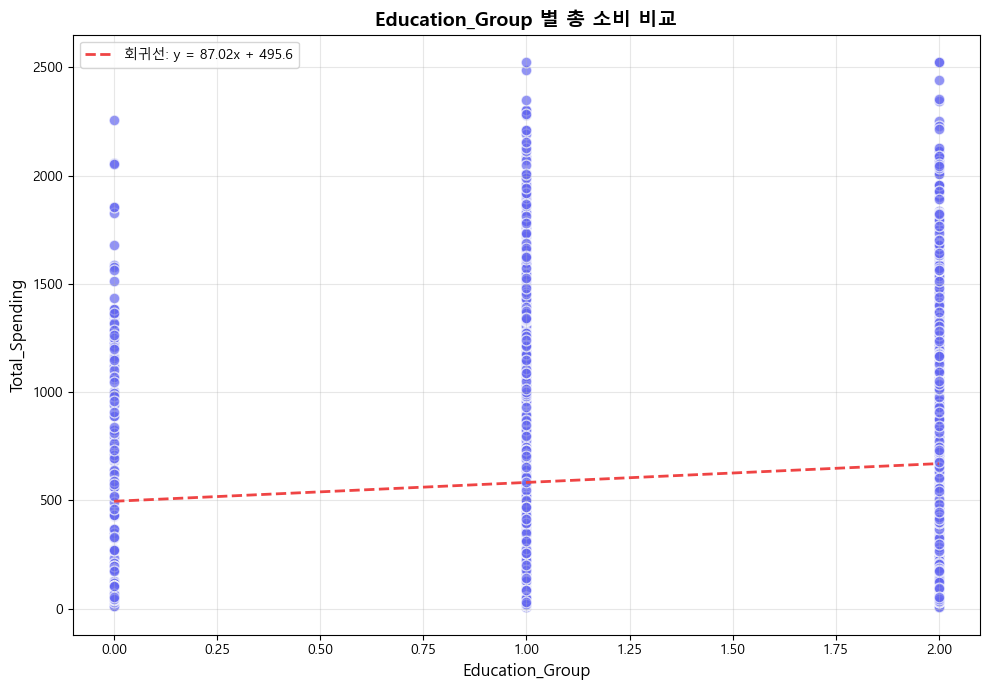

In [38]:
# TODO 4-2(d): 시각화 — 그룹별 개별 데이터 산점도 + 평균 다이아몬드
group_mapping = {'Undergraduate': 0, 'Graduate': 1, 'Postgraduate': 2}
df['Group_Num'] = df['Education_Group'].map(group_mapping)
# 그룹별, 개별 데이터 산점도
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(df['Group_Num'], df['Total_Spending'], color='#6366F1', alpha=0.7, s=60, edgecolors='white')

# 회귀선 추가
z = np.polyfit(df['Group_Num'],df['Total_Spending'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Group_Num'].min(), df['Group_Num'].max(), 100)
ax.plot(x_line, p(x_line), color='#EF4444', linewidth=2, linestyle='--',
        label=f'회귀선: y = {z[0]:.2f}x + {z[1]:.1f}')


ax.set_xlabel('Education_Group', fontsize=12)
ax.set_ylabel('Total_Spending', fontsize=12)
ax.set_title('Education_Group 별 총 소비 비교', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 평균 다이아몬드
means = df.groupby('Group_Num')['Total_Spending'].mean()
sems = df.groupby('Group_Num')['Total_Spending'].sem()  # 표준오차

for x_val in means.index:
    ax.errorbar(x_val, means[x_val], yerr=sems[x_val],
                fmt='D', color='red', markersize=10)

### 문제 4-3. 카이제곱 독립성 검정

**가설**: 결혼 상태(Marital_Group)와 캠페인 반응(Campaign_Response)은 독립인가?

- H₀: Marital_Group과 Campaign_Response는 독립이다.
- H₁: 두 변수는 독립이 아니다.

- 효과크기: φ (phi) = √(χ² / n) (기준: 0.1 작은, 0.3 중간, 0.5 큰)
- 오즈비(Odds Ratio): OR = (a×d) / (b×c), 95% CI = exp(ln(OR) ± 1.96 × SE)

> ⚠️ Cochran 규칙: 기대빈도 < 5인 셀이 전체의 20% 초과 시 Fisher 정확검정 필요

In [39]:
crosstab_no_margin = pd.crosstab(df['Marital_Group'], df['Campaign_Response'])
display(crosstab_no_margin)
# TODO 4-3(a): 카이제곱 검정 수행 + Cochran 규칙 확인
observed = np.array(crosstab_no_margin) 
chi2, p, dof, expected = stats.chi2_contingency(crosstab_no_margin)
n_under5_sm = np.sum(expected < 5)
pct_under5_sm = n_under5_sm / len(expected)
n_under1_sm = np.sum(expected < 1)

is_cond = False if ((n_under1_sm >= 1) or pct_under5_sm >= 0.2) else True
print(is_cond, n_under1_sm, pct_under5_sm)

n_total = observed.sum() # 표본수
cohens_w = np.sqrt(chi2 / n_total)
if abs(cohens_w) < 0.5:
    print(f"해석: Cohen's w(값: {cohens_w:.4f})은 작은 효과이다.")
elif abs(cohens_w) < 0.8:
    print(f"해석: Cohen's d(값: {cohens_w:.4f})은 중간 효과이다.")
else:
    print(f"해석: Cohen's d(값: {cohens_w:.4f})은 큰 효과이다.")


# TODO 4-3(b): φ (phi) 계산
N_f = crosstab_no_margin.values.sum()
phi = np.sqrt(chi2 / N_f)
print(f"phi 값: {phi:.4f}")

# TODO 4-3(c): 오즈비(Odds Ratio) + 95% CI 계산
odd_ratio, fisher_p = stats.fisher_exact(crosstab_no_margin)
print(f"오즈비: {odd_ratio:.4f}")
print("     -> 해석: 결혼 상태의 그룹이 캠페인에 응답할 확률이 다른 그룹보다 약 0.74배 높다.")

# 95% CI 계산
data_marry = df['Total_Spending']
n = len(data_marry)
xbar= np.mean(n)
s = np.std(data_marry, ddof=1)
se = s / np.sqrt(n)

alpha = 0.05
t_crit = stats.t.ppf(1-alpha/2, df=n-1)
margin = t_crit * se

ci_low = xbar - margin
ci_high = xbar + margin

print(f"신뢰수준 {0.95} CI: {ci_low:.4f}, {ci_high:.4f}") 

Campaign_Response,False,True
Marital_Group,,
Single,547,247
Together,1081,361


True 0 0.0
해석: Cohen's w(값: 0.0643)은 작은 효과이다.
phi 값: 0.0643
오즈비: 0.7396
     -> 해석: 결혼 상태의 그룹이 캠페인에 응답할 확률이 다른 그룹보다 약 0.74배 높다.
신뢰수준 0.95 CI: 2211.0399, 2260.9601


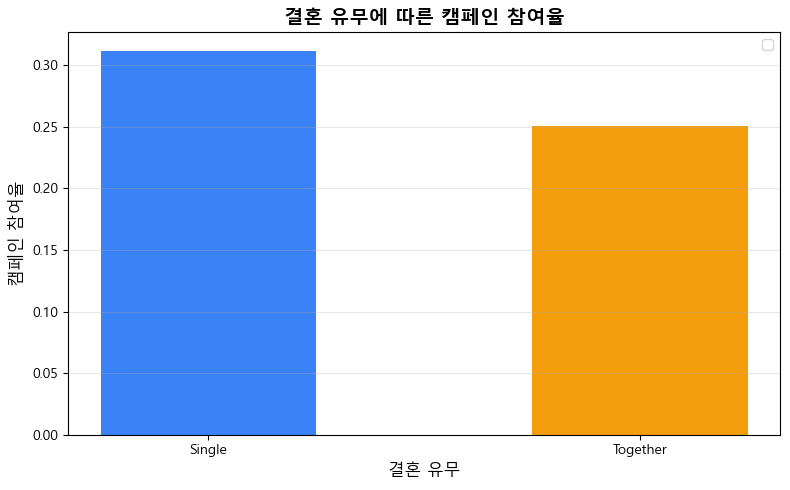

In [40]:
# TODO 4-3(d): (1) 결혼 상태별 반응률 막대그래프 (2) 표준화 잔차 히트맵
grouped = df.groupby('Marital_Group')['Campaign_Response'].mean()
marital_labels = grouped.index
response_rate = grouped.values
# (1) 결혼 상태별 반응률 막대그래프 
colors = ['#3B82F6', '#F59E0B']
plt.subplots(figsize=(8, 5))
plt.bar(marital_labels, response_rate,color=colors, width = 0.5)
plt.xlabel('결혼 유무', fontsize=12)
plt.ylabel('캠페인 참여율', fontsize=12)
plt.title(f'결혼 유무에 따른 캠페인 참여율', fontsize=14, fontweight='bold')
plt.xticks()
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# (2) 표준화 잔차 히트맵

### 문제 4-4. 적합도 검정

3개 구매 채널(Web, Catalog, Store)의 총 구매 비율이 균등하게 분포하는지 검정합니다.

- H₀: 세 채널의 구매 비율이 동일하다 (1/3 : 1/3 : 1/3)
- H₁: 세 채널의 구매 비율이 동일하지 않다

Cohen's w = √(Σ(p_obs - p_exp)² / p_exp)

In [41]:
channel_totals = df[purchase_cols].sum()
channel_names = ['Web', 'Catalog', 'Store']
observed = channel_totals.values

# TODO 4-4(a): 기대빈도(균등) 계산 + 적합도 검정

n_total = observed.sum()
n_channels = len(observed)
expected = np.array([n_total / n_channels] * n_channels)
print("기대빈도: ", expected)

chi2_stat, p_value = stats.chisquare(observed, expected)
print("Chi2 Statistic:", chi2_stat)
print("p-value:", p_value)

# TODO 4-4(b): Cohen's w 계산
cohens_channel = np.sqrt(chi2 / n_total)
if abs(cohens_channel) < 0.5:
    print(f"해석: Cohen's w(값: {cohens_channel:.4f})은 작은 효과이다.")
elif abs(cohens_channel) < 0.8:
    print(f"해석: Cohen's d(값: {cohens_channel:.4f})은 중간 효과이다.")
else:
    print(f"해석: Cohen's d(값: {cohens_channel:.4f})은 큰 효과이다.")
print("Cohen's w:", cohens_channel)



기대빈도:  [9351.33333333 9351.33333333 9351.33333333]
Chi2 Statistic: 2630.1062950024952
p-value: 0.0
해석: Cohen's w(값: 0.0181)은 작은 효과이다.
Cohen's w: 0.018145226620267418


[ 9140  5955 12959]


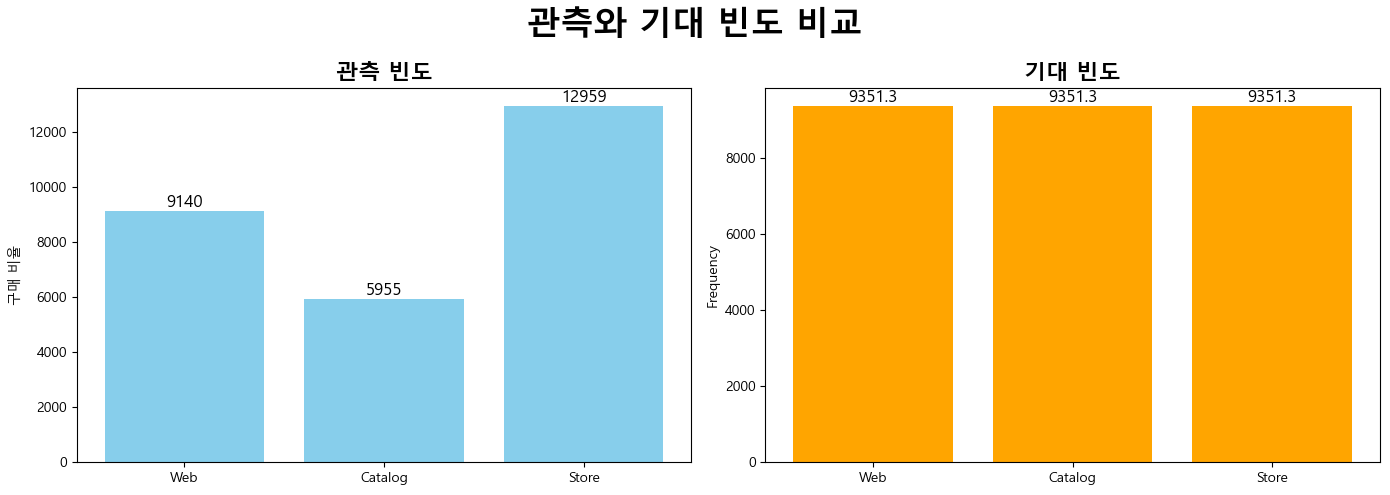

In [42]:
# TODO 4-4(c): 관측 vs 기대(균등) 비교 막대그래프
# 관측 빈도
ct_raw = channel_totals
ct_obs = ct_raw.values
print(ct_obs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(ct_obs))
axes[0].bar(x, ct_obs, color='skyblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(channel_names)
axes[0].set_ylabel('구매 비율')
axes[0].set_title('관측 빈도', fontsize=16, fontweight='bold')
for i, val in enumerate(ct_obs):
    axes[0].text(i, val + 0.5, f'{val}', ha='center', va='bottom', fontsize=12)

# 기대 빈도 막대그래프
axes[1].bar(x, expected, color='orange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(channel_names)
axes[1].set_ylabel('Frequency')
axes[1].set_title('기대 빈도', fontsize=16, fontweight='bold')
# val: 막대 높이
# ha: x축 정렬 / va = 지정좌표의 위치 (var+숫자)는 막대 위에 텍스트가 올라감
for i, val in enumerate(expected):
    axes[1].text(i, val + 0.5, f'{val:.1f}', ha='center', va='bottom', fontsize=12)

fig.suptitle("관측와 기대 빈도 비교", fontsize=24, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 5: 상관분석 / 비율 비교 — "변수 간 관계를 파악하고, 캠페인 효과를 검증할 수 있는가?"

변수 간 상관관계를 분석하고, A/B 테스트로 캠페인 효과를 검증합니다.

### 문제 5-1. 상관분석

6개 변수의 Pearson/Spearman 상관계수를 계산하고 히트맵으로 시각화하세요.
주요 변수 쌍에 대해 유의성 검정도 수행합니다.

In [43]:
corr_vars = ['Income', 'Age', 'Total_Spending', 'Total_Purchases',
             'NumWebVisitsMonth', 'Recency']
df_corr_vars = df[corr_vars]
# TODO 5-1(a): Pearson/Spearman 상관행렬 계산
# 피어슨 상관계수 계산
print("\n a-1) 피어슨 상관계수 (Pearson r)")
# 범위: -1 ≤ r ≤ 1 (1: 완벽한 양의 선형, 0: 선형 관계 없음, -1: 완벽한 음의 선형)
pairs = [
    ('Income', 'Total_Spending'),
    ('Income', 'Total_Purchases'),
    ('Age', 'Recency')
]

for var1, var2 in pairs:
    r_pearson, p_pearson = stats.pearsonr(df[var1], df[var2])
    size= 0
    if abs(r_pearson)<0.3:
        size = '약한'
    elif abs(r_pearson)<0.7:
        size = '중간'
    else :
        size = '강한'
    
    direction = 0
    if r_pearson >0:
        direction = '양의'
    else:
        direction = '음의'
    print(f"{var1} vs {var2}: r={r_pearson:.4f} ({size} {direction} 상관), p={p_pearson:.4f}")
    print(f"결정계수 r²={r_pearson**2:.4f}, 설명력: {r_pearson**2*100:.4f}%")
    
# TODO: 스피어만 상관계수 계산 (stats.spearmanr)
# r_spearman, p_spearman = stats.spearmanr(df[var3],df[var4])
# 여러 변수 상관행렬 계산일 경우, 내장함수를 이용해야 함
print(f"\n a-2) 스피어만 상관계수 (Spearman ρ)")
for var3, var4 in pairs:
    r_spearman, p_spearman = stats.spearmanr(df[var3], df[var4])
    size= 0
    if abs(r_spearman)<0.3:
        size = '약한'
    elif abs(r_spearman)<0.7:
        size = '중간'
    else :
        size = '강한'
    
    direction = 0
    if r_spearman >0:
        direction = '양의'
    else:
        direction = '음의'
    print(f"{var3} vs {var4}: ρ={r_spearman:.4f} ({size} {direction} 상관))")


# TODO 5-1(b): 주요 상관계수 쌍의 유의성 검정 (stats.pearsonr)
print("\n b) 주요 상관계수 쌍의 유의성 검정: ")
alpha = 0.05
sig = 0
if p_pearson < alpha:
    sig = '유의함 (p < 0.05)'
else:
    sig = '유의하지 않음 (p ≥ 0.05)'
    
    print(f"{var1} vs {var2}: r={r_pearson:.4f}, p={p_pearson:.4f} → {sig}")


 a-1) 피어슨 상관계수 (Pearson r)
Income vs Total_Spending: r=0.7894 (강한 양의 상관), p=0.0000
결정계수 r²=0.6231, 설명력: 62.3113%
Income vs Total_Purchases: r=0.7386 (강한 양의 상관), p=0.0000
결정계수 r²=0.5456, 설명력: 54.5600%
Age vs Recency: r=0.0194 (약한 양의 상관), p=0.3593
결정계수 r²=0.0004, 설명력: 0.0376%

 a-2) 스피어만 상관계수 (Spearman ρ)
Income vs Total_Spending: ρ=0.8495 (강한 양의 상관))
Income vs Total_Purchases: ρ=0.7768 (강한 양의 상관))
Age vs Recency: ρ=0.0201 (약한 양의 상관))

 b) 주요 상관계수 쌍의 유의성 검정: 
Age vs Recency: r=0.0194, p=0.3593 → 유의하지 않음 (p ≥ 0.05)


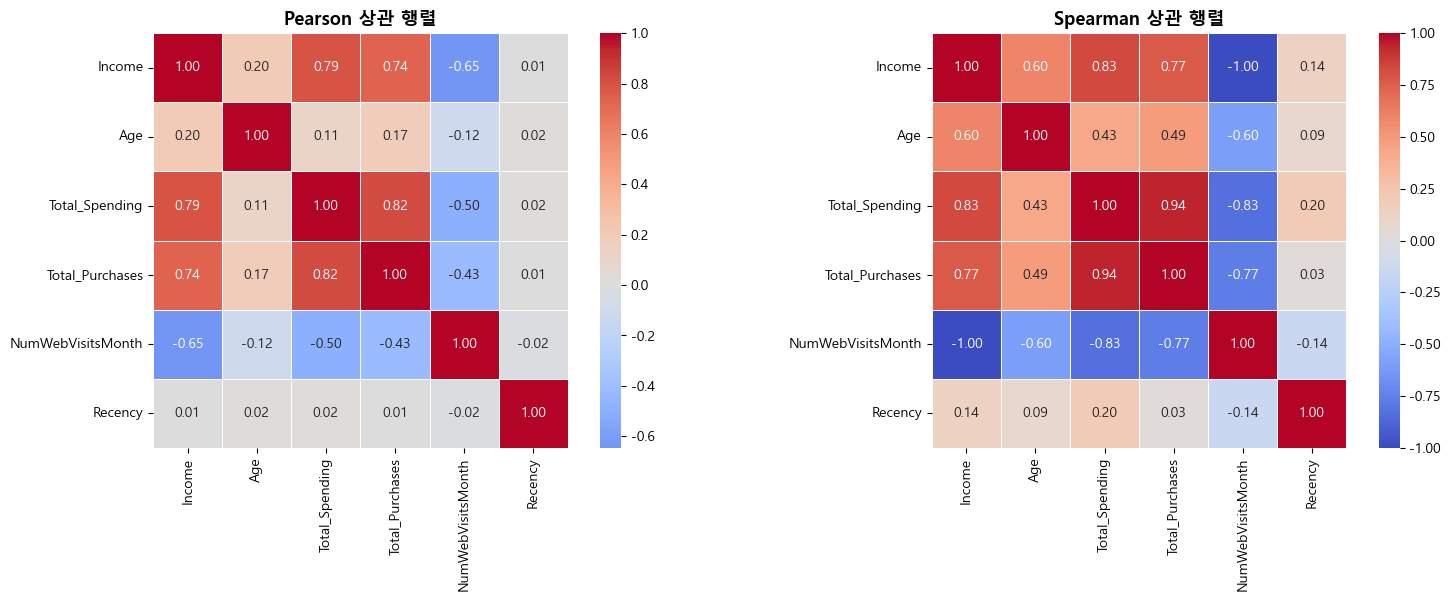

In [44]:
# TODO 5-1(c): 상관행렬 히트맵 (Pearson + Spearman, 1×2 서브플롯)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pearson
corr_vars_p = df_corr_vars.corr()
sns.heatmap(corr_vars_p, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title('Pearson 상관 행렬', fontsize=13, fontweight='bold')

# Spearman
corr_vars_s = df_corr_vars.corr()
sns.heatmap(corr_vars_s.corr(method='spearman'), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, linewidths=0.5, ax=axes[1])
axes[1].set_title('Spearman 상관 행렬', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

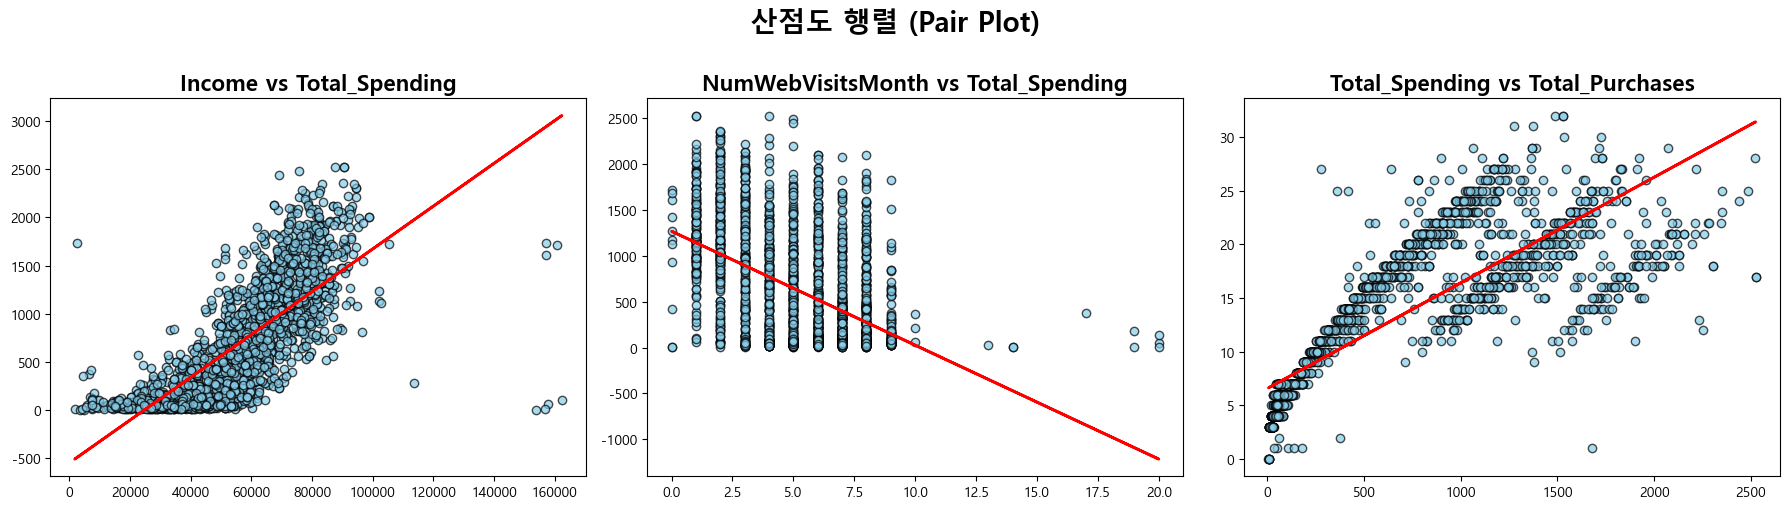

In [45]:
# TODO 5-1(d): 주요 변수 쌍 산점도 + 추세선 (1×3 서브플롯)
# 대상: (Income, Total_Spending), (NumWebVisitsMonth, Total_Spending), (Total_Spending, Total_Purchases)
# np.polyfit()으로 1차 추세선을 그리세요
scatter_pairs = [
    ('Income', 'Total_Spending'),
    ('NumWebVisitsMonth', 'Total_Spending'),
    ('Total_Spending', 'Total_Purchases')
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (x_var, y_var) in enumerate(scatter_pairs):
    x = df[x_var]
    y = df[y_var]
    
    # 산점도
    axes[i].scatter(x, y, color='skyblue', edgecolor='k', alpha=0.7)
    
    # 1차 추세선
    coeffs = np.polyfit(x, y, deg=1)       
    trendline = np.poly1d(coeffs)          
    axes[i].plot(x, trendline(x), color='red', linewidth=2, label='Trendline')
    axes[i].set_title(f"{x_var} vs {y_var}", fontsize=16, fontweight='bold')
plt.suptitle('산점도 행렬 (Pair Plot)', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 문제 5-2. 두 그룹 비율 비교 (관찰 연구)

이전 캠페인 반응 경험 유무에 따라 마지막 캠페인(Response) 수락률에 차이가 있는지 검증합니다.

- **Group A**: AcceptedCmp1~5 합계 = 0 (이전 캠페인 무반응)
- **Group B**: AcceptedCmp1~5 합계 ≥ 1 (이전 캠페인 반응 경험)
- **지표**: Response (마지막 캠페인 수락률)
- **검정 방법**: z-비율검정 + Cohen's h + Wilson 신뢰구간

> **주의**: 이 분석은 A/B 테스트가 **아닙니다**. \
> A/B 테스트는 연구자가 참가자를 **무작위로 배정** (Random Assignment)하는 실험입니다. \
> 여기서는 고객이 과거 행동에 의해 스스로 그룹에 배정되었으므로 **관찰 연구**이며, \
> 인과관계를 주장할 수 없습니다.

In [46]:
cmp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
df['Prior_Response'] = df[cmp_cols].sum(axis=1)

group_a = df[df['Prior_Response'] == 0]
group_b = df[df['Prior_Response'] >= 1]

n_a, n_b = len(group_a), len(group_b)
conv_a = group_a['Response'].sum()
conv_b = group_b['Response'].sum()
#평균
rate_a = conv_a / n_a
rate_b = conv_b / n_b

# 합동 비율
p_pool = (conv_a + conv_b) / (n_a + n_b)

# 표준오차
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_a + 1/n_b))

# TODO 5-2(a): z-비율검정
z = (rate_a - rate_b) / se
print(" a) z-score 검정")
print(f"z-score: {z:.4f}")

# TODO 5-2(b): Cohen's h 효과 크기
print("\n b) Cohen's h 효과 크기")

h = proportion_effectsize(rate_a, rate_b)
if abs(h) < 0.2:
    print(f"해석: Cohen's d(값: {h:.4f})은 매우 작은 효과이다.")
elif abs(h) < 0.5:
    print(f"해석: Cohen's d(값: {h:.4f})은 작은 효과이다.")
elif abs(h) < 0.8:
    print(f"해석: Cohen's d(값: {h:.4f})은 중간 효과이다.")
else:
    print(f"해석: Cohen's d(값: {h:.4f})은 큰 효과이다.")

# TODO 5-2(c): Wilson 신뢰구간
print("\n c) Wilson 신뢰 구간")
ci_a = proportion_confint(conv_a.sum(), n_a, alpha=0.05, method='wilson')
ci_b = proportion_confint(conv_b.sum(), n_b, alpha=0.05, method='wilson')

print(f"Group A 전환율: {rate_a:.4f}")
print(f"  95% CI: [{ci_a[0]:.4f}, {ci_a[1]:.4f}]")

print(f"Group B 전환율: {rate_b:.4f}")
print(f"  95% CI: [{ci_b[0]:.4f}, {ci_b[1]:.4f}]")

 a) z-score 검정
z-score: -17.4357

 b) Cohen's h 효과 크기
해석: Cohen's d(값: -0.8016)은 큰 효과이다.

 c) Wilson 신뢰 구간
Group A 전환율: 0.0823
  95% CI: [0.0704, 0.0960]
Group B 전환율: 0.4069
  95% CI: [0.3631, 0.4523]


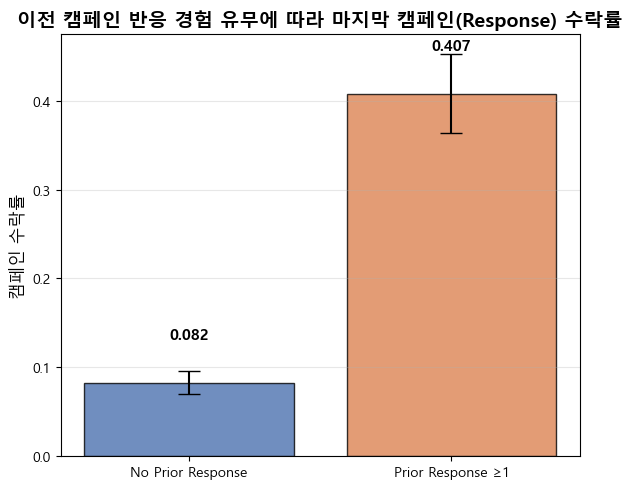

In [47]:
# TODO 5-2(d): 수락률 비교 시각화 (CI 오차막대 포함)
labels = ['No Prior Response', 'Prior Response ≥1']
colors = ['#4C72B0', '#DD8452']
rates = [rate_a, rate_b]
errors = [
    [rate_a - ci_a[0], rate_b - ci_b[0]],   
    [ci_a[1] - rate_a, ci_b[1] - rate_b]]

fig, ax = plt.subplots(figsize=(6,5))

bars = ax.bar(labels, rates, yerr=errors,
              capsize=8, color=colors,
              alpha=0.8, edgecolor='black')
# ═══ 평균값 텍스트 표시 ═══
# 각 막대 위에 평균값을 숫자로 표시
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 0.045,
            f'{rate:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('캠페인 수락률', fontsize=12)
ax.set_title('이전 캠페인 반응 경험 유무에 따라 마지막 캠페인(Response) 수락률', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

> ⚠️ **이 분석이 A/B 테스트가 아닌 이유**
>
> A/B 테스트의 본질은 '무작위 배정(Random Assignment)'입니다.
>
> - **A/B 테스트**: 연구자가 참가자를 무작위로 배정 → 인과관계 추론 가능
> - **이 분석**: 고객의 과거 행동으로 그룹이 결정 → 관찰 연구, 인과관계 주장 불가
>
> → 인과관계를 검증하려면 무작위 배정 실험(RCT)을 설계해야 합니다. (문제 5-3)

### 문제 5-3. 진정한 A/B 테스트 설계

새로운 캠페인이 기존 수락률 대비 **2%p** 개선을 가져올 수 있는지 탐지하기 위한
최소 표본 크기를 산정하세요. (α=0.05, Power=0.80)

In [48]:
baseline_rate = df['Response'].mean()
target_rate = baseline_rate + 0.02

# TODO 5-3(a): Cohen's h 계산
print("\n a) Cohen's h 계산")

h = abs(proportion_effectsize(baseline_rate, target_rate))
if h < 0.2:
    print(f"해석: Cohen's d(값: {h:.4f})은 매우 작은 효과이다.")
elif h < 0.5:
    print(f"해석: Cohen's d(값: {h:.4f})은 작은 효과이다.")
elif  h < 0.8:
    print(f"해석: Cohen's d(값: {h:.4f})은 중간 효과이다.")
else:
    print(f"해석: Cohen's d(값: {h:.4f})은 큰 효과이다.")

# TODO 5-3(b): NormalIndPower()로 필요 표본 크기 산정 (α=0.05, Power=0.80, 단측)
print("\n b): NormalIndPower()로 필요 표본 크기 산정 (α=0.05, Power=0.80, 단측)")
power_analysis = NormalIndPower()
sample_size = power_analysis.solve_power(
    effect_size=h,
    alpha=0.05,
    power=0.8,
    alternative='larger')
sample_size = int(np.ceil(sample_size))

if sample_size is not None:
    sample_size = int(np.ceil(sample_size))
    print(f"\n  집단당 필요 표본 크기: {sample_size:,}명")
    print(f"  총 필요 표본 크기: {sample_size * 2:,}명")


 a) Cohen's h 계산
해석: Cohen's d(값: 0.0547)은 매우 작은 효과이다.

 b): NormalIndPower()로 필요 표본 크기 산정 (α=0.05, Power=0.80, 단측)

  집단당 필요 표본 크기: 4,138명
  총 필요 표본 크기: 8,276명


---
## Challenge: 종합 분석 보고서

지금까지의 분석을 종합하여 FreshCart 마케팅팀에 제출할 보고서를 작성합니다.

### Challenge 1. 고객 그룹별 특성 분석

`Income_Group` × `Has_Children` 6개 조합에 대해 다음을 포함하는 종합 분석표를 작성하세요:

- 고객 수, 평균 소득, 평균/중앙값 소비, 평균 구매 수, 캠페인 반응률, 웹 방문 수
- 그룹 비교 시각화 (1×3 서브플롯: 평균 소비, 반응률, 고객 수)

In [49]:
print(df.columns)

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Spending', 'Total_Purchases', 'Total_Accepted',
       'Has_Children', 'Income_Group', 'Age_Group', 'Education_Group',
       'Marital_Group', 'Campaign_Response', 'Customer_Days', 'Children_Label',
       'Group_Num', 'Prior_Response'],
      dtype='str')


In [ ]:
# TODO C-1: 고객 그룹별 특성 분석 종합표 + 시각화
purchase_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
                 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
purchase_count_cols = ['NumWebPurchases', 'NumCatalogPurchases',
                       'NumStorePurchases']
df['Total_Purchases'] = df[purchase_count_cols].sum(axis=1)
df['Total_Spending'] = df[purchase_cols].sum(axis=1)

group_table = (
    df.groupby(['Income_Group', 'Has_Children']).agg(
        고객수=('Income', 'count'),
        평균소득=('Income', 'mean'),
        평균소비=('Total_Spending', 'mean'),
        중앙값소비=('Total_Spending', 'median'),
        평균구매수=('Total_Purchases', 'mean'), 
        캠페인반응률=('Campaign_Response', 'mean'),
        평균웹방문수=('NumWebVisitsMonth', 'mean')
    )
    .reset_index()
)

display(group_table)

#시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 보기 좋은 그룹 라벨 생성
group_table['Group'] = (
    group_table['Income_Group'].astype(str) + " | " +
    group_table['Has_Children'].astype(str)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ① 평균 소비
sns.barplot(
    ax=axes[0],
    data=group_table,
    x='Group',
    y='평균소비'
)
axes[0].set_title('그룹별 평균 소비')
axes[0].tick_params(axis='x', rotation=45)

# ② 캠페인 반응률
sns.barplot(
    ax=axes[1],
    data=group_table,
    x='Group',
    y='캠페인반응률'
)
axes[1].set_title('그룹별 캠페인 반응률')
axes[1].tick_params(axis='x', rotation=45)

# ③ 고객 수
sns.barplot(
    ax=axes[2],
    data=group_table,
    x='Group',
    y='고객수'
)
axes[2].set_title('그룹별 고객 수')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


,Income_Group,Has_Children,고객수,평균소득,평균소비,중앙값소비,평균구매수,캠페인반응률,평균웹방문수
0,Low,False,115,24380.243478,145.008696,73.0,6.400000,0.130435,6.930435
1,Low,True,631,29172.879556,86.686212,54.0,5.670365,0.169572,6.901743
2,Mid,False,80,52209.631250,721.237500,653.0,15.362500,0.350000,4.675000
3,Mid,True,665,51466.093985,426.254135,368.0,12.338346,0.198496,5.869173
4,High,False,442,78697.963801,1424.024887,1383.0,19.219457,0.545249,2.366516
5,High,True,303,71841.607261,1033.115512,1005.0,19.178218,0.280528,4.679868


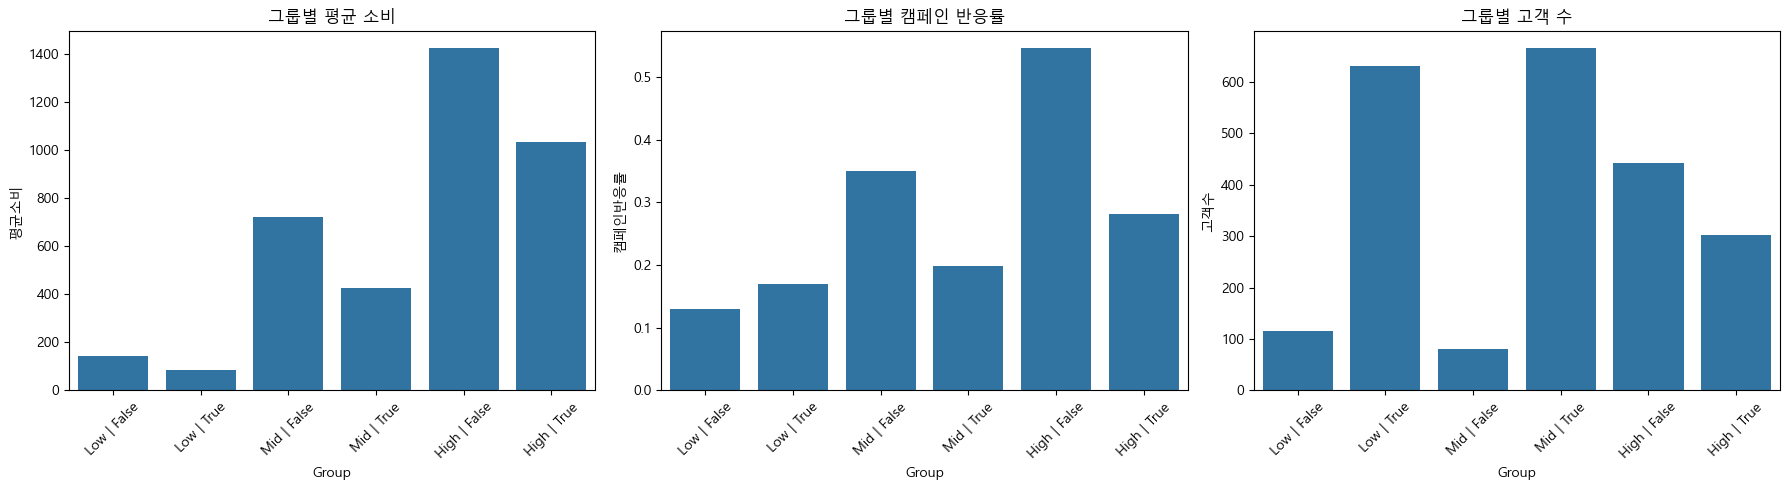

### Challenge 2. 비즈니스 제안서

분석 결과를 종합하여 다음을 포함하는 제안서를 작성하세요:

1. **타겟 고객**: 어떤 그룹를 우선 집중 공략해야 하는가? (근거 포함)
2. **채널 전략**: 소득 그룹별 최적 마케팅 채널은?
3. **기대 효과**: 집중 공략 기반 예상 개선 효과
4. **한계점**: 분석의 한계와 추가 필요 데이터

In [ ]:
# TODO C-2: 비즈니스 제안서 작성

---
## 수고하셨습니다!

설날 연휴 따뜻하고 복 가득한 시간 보내요! 💛